# FigSupplementary.ipynb

## Introduction
This notebook focuses on plotting supplementary figures.

In [1]:
# This notebook generates supplementary figures (Fig S1, Fig S2, etc.) for the project.
# The code uses various statistical tests and plots to visualize data distributions
# and relationships (e.g., Mann-Whitney U, Levene, Kruskal-Wallis, violin plots).

from Utils import PlotUtlis, create_folder, mm2inch, set_mpl_defaults, convert_to_env_list_detail, get_significance_stars
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy.stats import mannwhitneyu, levene, friedmanchisquare, wilcoxon, rankdata, spearmanr
from matplotlib.colors import ListedColormap
import cv2
import matplotlib.lines as mlines
import numpy.ma as ma
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import csv
import json
import itertools
from statsmodels.stats.multitest import multipletests
import rasterio
from rasterio.warp import reproject, calculate_default_transform, Resampling
import matplotlib.ticker as mtick

set_mpl_defaults()

In [2]:
# Define run ID, experiment ID, and niche raster size.
# These settings will be used to initialize the PlotUtlis class.
run_id = 'a21e809cf92c477c8e6f67a638adcb03'
exp_id = '560401789505105998'

In [3]:
# Instantiate PlotUtlis with the specified run/experiment IDs.
PU = PlotUtlis(run_id = run_id, exp_id = exp_id)

In [4]:
# Create a folder for supplementary figures if it does not already exist.
create_folder(PU.plot_path_suppl)

## Fig. S1

### **Attention score analysis and variable selection workflow**

This code performs a comprehensive analysis of **environmental variable importance** in the SEAM-SDM model using attention scores across species.  
It begins by loading and normalizing the attention data, then computes descriptive statistics and confidence intervals for each environmental factor.  

The workflow proceeds through several analytical steps:

1. **Data processing:**  
   The script detects whether the attention data are in long or wide format, pivots if necessary, and removes missing values to create a standardized matrix of *species × environmental variables*.

2. **Summary statistics and bootstrap confidence intervals:**  
   For each variable, the code calculates the **median attention score**, **interquartile range**, and **Top-3 coverage** (the proportion of species where the variable ranks among the top three).  
   Bootstrap resampling (1,000 iterations) generates 95% confidence intervals for these statistics.

3. **Core and extended variable selection:**  
   Variables in the top 25% of median attention and with high coverage are classified as **core predictors**, while moderately important and weakly correlated variables are included as **extended predictors**.

4. **Statistical significance tests:**  
   A **Friedman test** evaluates overall differences among variables, followed by **pairwise Wilcoxon tests** with **Holm correction** to identify significant pairwise differences and a “top statistical group” of strongest predictors.

5. **Output and visualization:**  
   The results are saved as CSV/JSON files and visualized with bar plots showing **median attention** and **Top-3 coverage** with 95% bootstrap CIs, providing interpretable rankings of variable importance.


In [36]:
# ---------- 1) Load and normalize the attention data into a wide matrix [species x variables] ----------

def load_attention_table(csv_path):
    df = pd.read_csv(csv_path)
    
    # Try to detect "long" vs "wide" formats
    cols_lower = {c: c.lower() for c in df.columns}
    df.columns = [c.strip() for c in df.columns]
    
    # Heuristics for long format
    long_candidate_cols = [c for c in df.columns if c.lower() in ["species", "sp", "物種", "taxon", "taxa"]]
    var_cols = [c for c in df.columns if c.lower() in ["variable", "predictor", "env", "environment", "環境因子"]]
    val_cols = [c for c in df.columns if c.lower() in ["attention", "attention_score", "value", "score"]]
    
    if long_candidate_cols and var_cols and val_cols:
        sp_col = long_candidate_cols[0]
        var_col = var_cols[0]
        val_col = val_cols[0]
        wide = df.pivot_table(index=sp_col, columns=var_col, values=val_col, aggfunc="mean")
        wide = wide.sort_index()
    else:
        # Wide format: assume first non-numeric column is species id (if any)
        nonnum = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
        if nonnum:
            sp_col = nonnum[0]
            wide = df.set_index(sp_col)
            # Keep only numeric columns
            wide = wide.select_dtypes(include=[np.number])
        else:
            # All numeric: create synthetic species ID
            wide = df.copy()
            wide.index = [f"sp_{i+1:03d}" for i in range(len(df))]
    # Drop columns with all NA; drop rows with any NA to keep paired tests valid
    wide = wide.dropna(axis=1, how="all")
    wide = wide.dropna(axis=0, how="any")
    # Ensure float
    wide = wide.astype(float)
    return wide

csv_path = PU.df_attention_path
X = load_attention_table(csv_path)
species_exclude = ['Tyto_longimembris', 'Synoicus_chinensis', 'Turnix_sylvaticus', 'Ketupa_flavipes']
X = X[~X.index.isin(species_exclude)]
n_species, n_vars = X.shape

In [37]:
# ---------- 2) Helper functions ----------

def top_k_coverage(df, k=3):
    """
    For each species (row), mark variables with value >= the kth largest value (tie-inclusive),
    then compute coverage per variable.
    """
    arr = df.values
    var_names = df.columns.tolist()
    counts = np.zeros(len(var_names), dtype=int)
    for i in range(arr.shape[0]):
        row = arr[i, :]
        # Get threshold for top-k (tie-inclusive)
        order = np.argsort(row)[::-1]
        kth_index = min(k-1, len(row)-1)
        kth_val = row[order[kth_index]]
        marks = row >= kth_val - 1e-12  # tolerance for float ties
        counts += marks.astype(int)
    coverage = counts / arr.shape[0]
    return pd.Series(coverage, index=var_names)


def bootstrap_ci(series_or_vals, alpha=0.05):
    """Generic bootstrap CI for a 1D array using median as statistic."""
    vals = np.asarray(series_or_vals, dtype=float)
    rng = np.random.default_rng(42)
    B = 1000
    n = len(vals)
    boots = np.empty(B)
    for b in range(B):
        idx = rng.integers(0, n, size=n)
        boots[b] = np.median(vals[idx])
    lo = np.quantile(boots, alpha/2)
    hi = np.quantile(boots, 1 - alpha/2)
    return lo, hi


def bootstrap_ci_bycol(df, stat="median", alpha=0.05, k_for_coverage=3):
    """
    Bootstrap CI for column-wise statistic (median or top-k coverage).
    """
    rng = np.random.default_rng(42)
    B = 1000
    n = df.shape[0]
    cols = df.columns.tolist()
    boot_stats = {c: [] for c in cols}
    if stat == "median":
        for b in range(B):
            idx = rng.integers(0, n, size=n)
            boot = df.iloc[idx]
            s = boot.median(axis=0)
            for c in cols:
                boot_stats[c].append(s[c])
    elif stat == "coverage":
        for b in range(B):
            idx = rng.integers(0, n, size=n)
            boot = df.iloc[idx]
            s = top_k_coverage(boot, k=k_for_coverage)
            for c in cols:
                boot_stats[c].append(s[c])
    # Build CI DF
    lo = {c: np.quantile(boot_stats[c], 0.025) for c in cols}
    hi = {c: np.quantile(boot_stats[c], 0.975) for c in cols}
    return pd.DataFrame({"lo": pd.Series(lo), "hi": pd.Series(hi)})


def holm_correction(pvals):
    """Holm-Bonferroni correction. Returns adjusted p-values in the original order."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(n, dtype=float)
    prev = 0.0
    for i, idx in enumerate(order):
        rank = i + 1
        adj_val = (n - i) * pvals[idx]
        adj_val = min(1.0, adj_val)
        # Ensure monotonicity
        if i == 0:
            prev = adj_val
        else:
            adj_val = max(adj_val, prev)
            prev = adj_val
        adj[idx] = adj_val
    return adj

In [38]:
# ---------- 3) Compute prior-rule metrics ----------

median_by_var = X.median(axis=0).sort_values(ascending=False)
q25 = X.quantile(0.25, axis=0)
q75 = X.quantile(0.75, axis=0)
coverage = top_k_coverage(X, k=3).loc[median_by_var.index]  # align order

# Bootstrap CIs
ci_med = bootstrap_ci_bycol(X, stat="median", alpha=0.05)
ci_cov = bootstrap_ci_bycol(X, stat="coverage", alpha=0.05)

summary = pd.DataFrame({
    "median_attention": X.median(axis=0),
    "q25": q25,
    "q75": q75,
    "top3_coverage": coverage
})
# Attach CIs
summary["median_lo95"] = ci_med.loc[summary.index, "lo"]
summary["median_hi95"] = ci_med.loc[summary.index, "hi"]
summary["coverage_lo95"] = ci_cov.loc[summary.index, "lo"]
summary["coverage_hi95"] = ci_cov.loc[summary.index, "hi"]
summary["rank_by_median"] = summary["median_attention"].rank(ascending=False, method="min").astype(int)
summary["rank_by_coverage"] = summary["top3_coverage"].rank(ascending=False, method="min").astype(int)
summary = summary.sort_values("median_attention", ascending=False)
summary

,median_attention,q25,q75,top3_coverage,median_lo95,median_hi95,coverage_lo95,coverage_hi95,rank_by_median,rank_by_coverage
landcover_PC03,0.148855,0.121758,0.174630,0.991736,0.140050,0.159244,0.975207,1.000000,1,1
hurs,0.131575,0.114303,0.145325,0.991736,0.126310,0.137429,0.975207,1.000000,2,1
landcover_PC01,0.126065,0.111419,0.136860,0.991736,0.121667,0.130801,0.975207,1.000000,3,1
EVI,0.119714,0.108578,0.127168,0.000000,0.116537,0.123100,0.000000,0.000000,4,7
landcover_PC04,0.109913,0.103434,0.112122,0.000000,0.108272,0.111288,0.000000,0.000000,5,7
clt,0.098028,0.096192,0.098779,0.008264,0.097577,0.098382,0.000000,0.024793,6,4
tas,0.073505,0.064357,0.082753,0.008264,0.069784,0.076562,0.000000,0.024793,7,4
sfcWind,0.062709,0.051273,0.075862,0.008264,0.057921,0.066860,0.000000,0.024793,8,4
rsds,0.057970,0.044551,0.073279,0.000000,0.052399,0.062849,0.000000,0.000000,9,7
landcover_PC02,0.041813,0.027763,0.061197,0.000000,0.035680,0.047560,0.000000,0.000000,10,7


In [39]:
# ---------- 4) Prior rule: Core and Extended sets ----------
# Thresholds
median_q75 = summary["median_attention"].quantile(0.75)
median_q50 = summary["median_attention"].quantile(0.50)

core = summary[(summary["median_attention"] >= median_q75) & (summary["top3_coverage"] >= 0.5)]
core_vars = core.index.tolist()

# Correlation check for extended (Spearman across species)
rho = X.corr(method="spearman")

extended_candidates = summary[
    (summary["median_attention"] >= median_q50) & 
    (summary["median_attention"] < median_q75) & 
    (summary["top3_coverage"] >= 0.4)
]

def max_abs_corr_with_set(var, varset, rho_mat):
    if not varset:
        return 0.0
    return float(np.max(np.abs(rho_mat.loc[var, varset].values)))

extended_vars = []
for var in extended_candidates.index:
    mac = max_abs_corr_with_set(var, core_vars, rho)
    if mac < 0.5:  # low correlation with any core variable
        extended_vars.append(var)

In [40]:
# ---------- 5) Significance evidence: Friedman + post-hoc Wilcoxon (Holm) ----------

# Friedman test
friedman_stat, friedman_p = friedmanchisquare(*[X[c].values for c in X.columns])

# Pairwise ordered one-sided Wilcoxon tests (u > v) across all ordered pairs; Holm correction
ordered_pairs = []
pvals = []
med_diffs = []
for i, j in itertools.permutations(range(n_vars), 2):
    vi = X.columns[i]
    vj = X.columns[j]
    # Skip duplicate direction if we already did (i,j) vs (j,i)? We need all ordered for "u>v" graph
    # We'll include all ordered pairs but will compute them once each time we hit (i,j).
    if vi == vj:
        continue
    d = X.iloc[:, i] - X.iloc[:, j]
    # Use Pratt method (includes zeros) to be conservative
    try:
        res = wilcoxon(X.iloc[:, i].values, X.iloc[:, j].values, alternative="greater", zero_method="pratt")
        p = res.pvalue
    except Exception:
        # Fallback: if all differences are zero, set p=1.0
        unique = np.unique(np.round(d.values, 12))
        p = 1.0 if len(unique) == 1 and unique[0] == 0 else 0.5
    ordered_pairs.append((vi, vj))
    pvals.append(p)
    med_diffs.append(float(np.median(d)))

# Holm correction
reject, pvals_holm, _, _ = multipletests(pvals, alpha=0.05, method="holm")

posthoc_df = pd.DataFrame({
    "var_left": [a for a, b in ordered_pairs],
    "var_right": [b for a, b in ordered_pairs],
    "median_diff_left_minus_right": med_diffs,
    "p_greater_raw": pvals,
    "p_greater_holm": pvals_holm,
    "reject_left_greater_than_right@0.05": reject
})

# Build "top statistical group": variables for which no other variable is significantly greater
vars_list = X.columns.tolist()
dominated = set()
for vi in vars_list:
    for vj in vars_list:
        if vi == vj:
            continue
        mask = (posthoc_df["var_left"] == vj) & (posthoc_df["var_right"] == vi)
        if not mask.any():
            continue
        if posthoc_df.loc[mask, "reject_left_greater_than_right@0.05"].any():
            dominated.add(vi)
            break
top_group = [v for v in vars_list if v not in dominated]

In [41]:
# ---------- 6) Save outputs ----------

outdir = PU.plot_path_suppl
summary_path = os.path.join(outdir, "attention_summary.csv")
posthoc_path = os.path.join(outdir, "posthoc_wilcoxon_holm.csv")
selection_path = os.path.join(outdir, "selected_variables_core_extended.json")

summary.to_csv(summary_path, index=True)
posthoc_df.to_csv(posthoc_path, index=False)
with open(selection_path, "w", encoding="utf-8") as f:
    json.dump({
        "core": core_vars,
        "extended": extended_vars,
        "median_q75": float(median_q75),
        "median_q50": float(median_q50),
        "friedman_statistic": float(friedman_stat),
        "friedman_pvalue": float(friedman_p),
        "top_statistical_group": top_group
    }, f, ensure_ascii=False, indent=2)

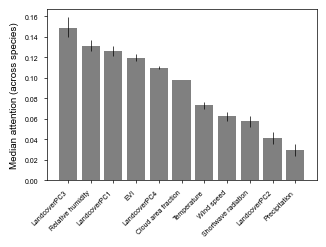

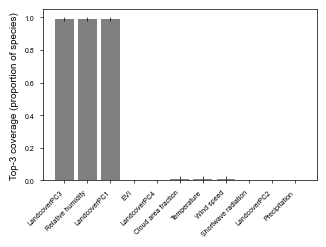

In [93]:
# ---------- 7) Visualizations: bar plots with 95% bootstrap CI ----------

# Plot 1: Median attention with 95% CI
plt.figure(figsize=mm2inch(80, 60), constrained_layout=True)
order = summary.sort_values("median_attention", ascending=False).index.tolist()
med_vals = summary.loc[order, "median_attention"].values
err_low = med_vals - summary.loc[order, "median_lo95"].values
err_high = summary.loc[order, "median_hi95"].values - med_vals
plt.bar(range(len(order)), med_vals, yerr=[err_low, err_high], color = 'gray')
plt.xticks(range(len(order)), convert_to_env_list_detail(order), rotation=45, ha="right")
plt.ylabel("Median attention (across species)")
plot1_path = os.path.join(outdir, "median_attention_CI.pdf")
plt.savefig(plot1_path, dpi=500, transparent=True)
plt.show()

# Plot 2: Top-3 coverage with 95% CI
plt.figure(figsize=mm2inch(80, 60), constrained_layout=True)
cov_vals = summary.loc[order, "top3_coverage"].values
cov_low = summary.loc[order, "coverage_lo95"].values
cov_high = summary.loc[order, "coverage_hi95"].values
err_low2 = cov_vals - cov_low
err_high2 = cov_high - cov_vals
plt.bar(range(len(order)), cov_vals, yerr=[err_low2, err_high2], color = 'grey')
plt.xticks(range(len(order)), convert_to_env_list_detail(order), rotation=45, ha="right")
plt.ylabel("Top-3 coverage (proportion of species)")
plot2_path = os.path.join(outdir, "top3_coverage_CI.pdf")
plt.savefig(plot2_path, dpi=500, transparent=True)
plt.show()

In [43]:
# ---------- 8) Display results as interactive tables ----------
print("\n[Attention summary]\n", summary.head(10))
print("\n[Pairwise post-hoc Wilcoxon (first 20 rows)]\n", posthoc_df.head(20))

# Final small text summary (printed)
print("\n--- Variable selection according to the prior rule ---")
print("Core variables:", core_vars)
print("Extended variables:", extended_vars)
print(f"Friedman test: chi2 = {friedman_stat:.3f}, p = {friedman_p:.3e}")
print("Top statistical group (no other variable significantly greater):", top_group)

# Provide artifact paths for download
print("\nArtifacts:")
print(f" - Summary CSV: {summary_path}")
print(f" - Post-hoc CSV: {posthoc_path}")
print(f" - Selection JSON: {selection_path}")
print(f" - Plot (median CI): {plot1_path}")
print(f" - Plot (coverage CI): {plot2_path}")


[Attention summary]
                 median_attention       q25       q75  top3_coverage  \
landcover_PC03          0.148855  0.121758  0.174630       0.991736   
hurs                    0.131575  0.114303  0.145325       0.991736   
landcover_PC01          0.126065  0.111419  0.136860       0.991736   
EVI                     0.119714  0.108578  0.127168       0.000000   
landcover_PC04          0.109913  0.103434  0.112122       0.000000   
clt                     0.098028  0.096192  0.098779       0.008264   
tas                     0.073505  0.064357  0.082753       0.008264   
sfcWind                 0.062709  0.051273  0.075862       0.008264   
rsds                    0.057970  0.044551  0.073279       0.000000   
landcover_PC02          0.041813  0.027763  0.061197       0.000000   

                median_lo95  median_hi95  coverage_lo95  coverage_hi95  \
landcover_PC03     0.140050     0.159244       0.975207       1.000000   
hurs               0.126310     0.137429       0

### **Landcover processing and PC-based forest vs non-forest analysis**

This script (1) **builds yearly landcover rasters aligned** to a reference grid, and (2) **tests how environmental landcover PCs differ** between **forest** and **non-forest** pixels across 2001–2018.

**Part A — Prepare yearly landcover rasters**
- Loads a **reference GeoTIFF** (`extent_binary.tif`) to get target transform/CRS/shape/profile.  
- For each year in the CCI configuration, opens the **CCI landcover netCDF layer**, reprojects it to the reference grid (nearest-neighbor for categorical data), and **writes a GeoTIFF** `landcover_raw_class_<YEAR>.tif` with `nodata=-9999`.

**Part B — Aggregate PCs by forest / non-forest**
- Defines **forest class codes** and a helper to map **PC columns** (PC1, PC3) by year (e.g., `landcover_PC01_2001-01-01`).  
- For each year (2001–2018): reads the landcover GeoTIFF, masks to the **study area** (via `PU.extent_binary`), splits pixels into **forest vs non-forest**, and pulls matching **PC1 / PC3** values from `PU.df_env_pca`.  
- Concatenates all years to get large samples for **PC1/PC3 in forest and non-forest**; optionally **downsamples** for speed.

**Part C — Summaries and statistical tests**
- Prints a quick summary (n, median, 2.5%/97.5% quantiles, unique values) for each group.  
- Computes **Cliff’s delta** (effect size) with **bootstrap 95% CI**, an **independent permutation test** (two-sided), and **Mann–Whitney U** (two-sided) for **PC1** and **PC3** (forest vs non-forest).  
- Saves results to `cc_effects.csv` and `cc_summary.csv`.

**Part D — Plots**
- If groups have sufficient unique values, draws **KDE curves** (else shared-bin histograms) comparing distributions for **forest vs non-forest** (PC1, PC3).  
- Produces **violin plots** (with medians and IQRs).  
- Exports figures as PDFs:  
  - `pc1_kde_or_hist.pdf`, `pc1_violin.pdf`  
  - `pc3_kde_or_hist.pdf`, `pc3_violin.pdf`


In [15]:
# Load reference grid to get transform, CRS, and profile
ref_path = os.path.join(PU.conf_path, 'extent_binary.tif')
with rasterio.open(ref_path) as ref:
    dst_transform = ref.transform       # target affine transform
    dst_crs       = ref.crs            # target coordinate reference system
    dst_width     = ref.width          # target width in pixels
    dst_height    = ref.height         # target height in pixels
    base_profile  = ref.profile.copy() # template profile for outputs

In [16]:
# Calculate the landcover raw class of each year (LONG TIME TO PROCESS)
create_folder(os.path.join(PU.plot_path_suppl, 'landcover_raw_tif'))
for i, conf in enumerate(PU.DeepSDM_conf.CCI_conf['landcover']):
    for yr in range(conf['year_coverages'][0], conf['year_coverages'][1]+1):
        src_path = f'NETCDF:{os.path.join(conf['raw_env_dir'], conf['filename_template'].replace('[YEAR]', str(yr)))}:{conf['layer_name']}'
        with rasterio.open(src_path) as src:
            src_data      = src.read(1)         # read the data array
            src_transform = src.transform       # source affine transform
            src_nodata = src.nodata
            # if the source CRS is missing, warn and assume reference CRS
            if src.crs is None:
                src_crs = dst_crs
            else:
                src_crs = src.crs

        # Allocate an array for reprojection output
        dest_array = np.full((dst_height, dst_width), -9999, dtype='int32')
        
        # Reproject using nearest-neighbor for categorical data
        reproject(
            source=src_data,
            destination=dest_array,
            src_transform=src_transform,
            src_crs=src_crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.nearest,
            src_nodata=src_nodata,
            dst_nodata=-9999
        )

        # Log the image 
        profile = base_profile
        profile.update({
            'driver': 'GTiff',
            'dtype': 'int32',
            'count': 1,
            'nodata': -9999,
            'transform': dst_transform,
            'crs': dst_crs
        })
        with rasterio.open(os.path.join(PU.plot_path_suppl, 'landcover_raw_tif', f'landcover_raw_class_{yr}.tif'), 'w', **profile) as dst:
            dst.write(dest_array, 1)

In [17]:
# parameters

# === Project objects ===
# Assume the PU object is available in the environment (contains df_env_pca and plot_path_attention)
df = PU.df_env_pca

# Years and column naming pattern
YEARS = list(range(2001, 2019))  # 2001–2018 (inclusive)
def pc_col(pc_num, year):
    # Use the Jan 1 column for each year
    return f"landcover_PC{pc_num:02d}_{year}-01-01"  # e.g., landcover_PC01_2001-01-01

# Forest class codes (adjust according to your 37-class schema)
FOREST_CODES = {50, 60, 61, 62, 70, 71, 72, 80, 81, 82, 90}  # Example; replace with your forest codes as needed

# Random downsampling cap for compute/plotting (two groups combined ≤ MAX_N; roughly half per group)
MAX_N = 300_000

# Output directory
OUTDIR = PU.plot_path_suppl

In [24]:
# Read yearly landcover rasters → flatten to 1D vectors (aligned with df rows)
def read_landcover_codes_for_year(year):
    path = os.path.join(PU.plot_path_suppl, 'landcover_raw_tif', f"landcover_raw_class_{year}.tif")
    with rasterio.open(path) as ds:
        arr = ds.read(1)
        flat = arr[PU.extent_binary == 1]  # Mask to study area
    return flat

In [25]:
# pool 2001–2018 across all pixel-years
pc1_forest, pc1_nonforest = [], []
pc3_forest, pc3_nonforest = [], []

for y in YEARS:
    # Read landcover codes
    lc_codes = read_landcover_codes_for_year(y)  # shape = (n_pixels,)
    is_valid_lc = ~np.isnan(lc_codes)
    is_forest = np.isin(lc_codes, list(FOREST_CODES)) & is_valid_lc
    
    # PC columns for the given year (use the Jan 1 column from df)
    col_pc1 = pc_col(1, y)
    col_pc3 = pc_col(3, y)
    if (col_pc1 not in PU.df_env_pca.columns) or (col_pc3 not in PU.df_env_pca.columns):
        raise KeyError(f"Missing columns in PU.df_env_pca: {col_pc1} or {col_pc3}")

    v_pc1 = PU.df_env_pca[col_pc1].to_numpy(np.float64)
    v_pc3 = PU.df_env_pca[col_pc3].to_numpy(np.float64)
    valid_pc1 = np.isfinite(v_pc1)
    valid_pc3 = np.isfinite(v_pc3)
    
    # Per-year per-pixel grouping: Forest vs. Non-forest
    mask1 = is_forest & valid_pc1
    mask0 = (~is_forest) & valid_pc1
    pc1_forest.append(v_pc1[mask1]); pc1_nonforest.append(v_pc1[mask0])
    
    mask1 = is_forest & valid_pc3
    mask0 = (~is_forest) & valid_pc3
    pc3_forest.append(v_pc3[mask1]); pc3_nonforest.append(v_pc3[mask0])

# Concatenate all years
pc1_forest = np.concatenate(pc1_forest) if pc1_forest else np.array([], dtype=float)
pc1_nonforest = np.concatenate(pc1_nonforest) if pc1_nonforest else np.array([], dtype=float)
pc3_forest = np.concatenate(pc3_forest) if pc3_forest else np.array([], dtype=float)
pc3_nonforest = np.concatenate(pc3_nonforest) if pc3_nonforest else np.array([], dtype=float)

# (Optional) Downsample to speed up plotting/permutation
def downsample_pair(x1, x0, max_total=MAX_N, seed=42):
    if max_total is None or max_total <= 0: 
        return x1, x0
    half = max_total // 2
    rng = np.random.default_rng(seed)
    def take(v): 
        return v if v.size <= half else v[rng.choice(v.size, size=half, replace=False)]
    return take(x1), take(x0)

pc1_forest_ds, pc1_nonforest_ds = downsample_pair(pc1_forest, pc1_nonforest, MAX_N)
pc3_forest_ds, pc3_nonforest_ds = downsample_pair(pc3_forest, pc3_nonforest, MAX_N)

# Quick summary
def quick_summ(arr):
    return dict(
        n=arr.size, 
        median=float(np.median(arr)),
        q2_5=float(np.percentile(arr, 2.5)),
        q97_5=float(np.percentile(arr, 97.5)),
        unique=int(np.unique(arr).size)
    )

summary = pd.DataFrame({
    "PC1_forest": quick_summ(pc1_forest),
    "PC1_nonforest": quick_summ(pc1_nonforest),
    "PC3_forest": quick_summ(pc3_forest),
    "PC3_nonforest": quick_summ(pc3_nonforest),
}).T
summary

,n,median,q2_5,q97_5,unique
PC1_forest,500119.0,0.429250,0.429250,0.429250,3.0
PC1_nonforest,328403.0,-0.629397,-0.750536,-0.508090,16.0
PC3_forest,500119.0,-0.013040,-0.013040,-0.013040,3.0
PC3_nonforest,328403.0,0.111924,-0.527606,0.725865,16.0


In [26]:
# Cliff's delta, bootstrap CI, permutation p, Mann–Whitney U
def cliffs_delta(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    nx, ny = len(x), len(y)
    r = rankdata(np.concatenate([x, y]), method="average")
    r1 = r[:nx].sum()
    A12 = (r1 / nx - (nx + 1)/2) / ny  # Vargha–Delaney A
    return 2*A12 - 1  # Cliff's δ

def bootstrap_ci_delta(x, y, B=2000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    nx, ny = len(x), len(y)
    boots = np.empty(B)
    for b in range(B):
        xb = x[rng.integers(0, nx, nx)]
        yb = y[rng.integers(0, ny, ny)]
        boots[b] = cliffs_delta(xb, yb)
    lo, hi = np.quantile(boots, [alpha/2, 1 - alpha/2])
    return float(lo), float(hi)

# Replacement permutation test for Cliff's delta: subsample when samples are huge
def perm_test_cliff(x, y, B=10_000, seed=42, max_perm_n=20_000):
    """
    Permutation test for Cliff’s delta.
    If len(x)+len(y) > max_perm_n, randomly downsample each group to half of max_perm_n,
    then run B permutations. Otherwise run the test on the full samples.
    """
    import numpy as np
    from scipy.stats import permutation_test

    n_total = len(x) + len(y)
    rng = np.random.default_rng(seed)

    # Downsample if samples are too large
    if n_total > max_perm_n:
        half = max_perm_n // 2
        x = x if len(x) <= half else rng.choice(x, half, replace=False)
        y = y if len(y) <= half else rng.choice(y, half, replace=False)

    def stat(a, b):
        return cliffs_delta(a, b)

    # Use SciPy's permutation_test (usually optimized)
    res = permutation_test(
        (x, y), stat,
        permutation_type="independent",
        alternative="two-sided",
        n_resamples=B,
        random_state=seed
    )
    return float(res.statistic), float(res.pvalue)


rows = []
for name, x1, x0 in [("PC1", pc1_forest_ds, pc1_nonforest_ds),
                     ("PC3", pc3_forest_ds, pc3_nonforest_ds)]:
    delta = cliffs_delta(x1, x0)
    lo, hi = bootstrap_ci_delta(x1, x0)
    stat, pperm = perm_test_cliff(x1, x0)
    mwu = mannwhitneyu(x1, x0, alternative="two-sided", method="auto")
    rows.append({
        "variable": name,
        "n_forest": int(x1.size), "n_nonforest": int(x0.size),
        "median_forest": float(np.median(x1)), "median_nonforest": float(np.median(x0)),
        "q02_5_forest": float(np.percentile(x1, 2.5)), "q02_5_nonforest": float(np.percentile(x0, 2.5)),
        "q97_5_forest": float(np.percentile(x1, 97.5)), "q97_5_nonforest": float(np.percentile(x0, 97.5)),
        "cliffs_delta": float(delta), "cliffs_delta_lo95": float(lo), "cliffs_delta_hi95": float(hi),
        "perm_statistic_delta": float(stat), "perm_pvalue_two_sided": float(pperm),
        "mannwhitney_u": float(mwu.statistic), "mannwhitney_p_two_sided": float(mwu.pvalue),
    })
effects = pd.DataFrame(rows)
display(effects)
effects.to_csv(os.path.join(OUTDIR, "cc_effects.csv"), index=False)
summary.to_csv(os.path.join(OUTDIR, "cc_summary.csv"))

,variable,n_forest,n_nonforest,median_forest,median_nonforest,q02_5_forest,q02_5_nonforest,q97_5_forest,q97_5_nonforest,cliffs_delta,cliffs_delta_lo95,cliffs_delta_hi95,perm_statistic_delta,perm_pvalue_two_sided,mannwhitney_u,mannwhitney_p_two_sided
0,PC1,150000,150000,0.42925,-0.629397,0.42925,-0.750536,0.42925,-0.508090,0.999995,0.999994,0.999996,0.999993,0.0002,2.249994e+10,0.0
1,PC3,150000,150000,-0.01304,0.111924,-0.01304,-0.527606,-0.01304,0.725865,-0.082901,-0.088036,-0.077887,-0.071993,0.0002,1.031736e+10,0.0


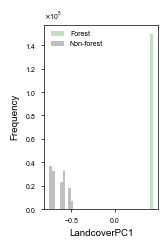

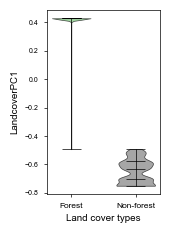

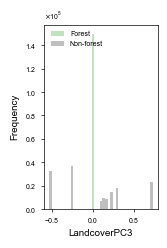

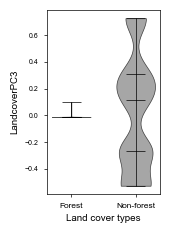

In [34]:
# plots
def plot_kde_or_hist(x1, x0, xlabel, path=None):
    fig, ax = plt.subplots(figsize=mm2inch(40, 60), 
                           gridspec_kw = {'left': 0.25, 'right': 0.97, 'bottom': 0.15, 'top': 0.93})

    u1, u0 = np.unique(x1).size, np.unique(x0).size

    if u1 >= 5 and u0 >= 5:
        # Use KDE when both groups have ≥5 unique values
        grid = np.linspace(min(x1.min(), x0.min()), max(x1.max(), x0.max()), 400)
        ax.plot(grid, gaussian_kde(x1)(grid), label="Forest", color=color_list[0])
        ax.plot(grid, gaussian_kde(x0)(grid), label="Non-forest", color=color_list[1])
    else:
        # Fall back to histograms with shared bins
        all_data = np.concatenate([x1, x0])
        bins = np.linspace(all_data.min(), all_data.max(), 40)  # adjust bin count if needed
        ax.hist(x1, bins=bins, density=False, alpha=0.5, label="Forest", color=color_list[0])
        ax.hist(x0, bins=bins, density=False, alpha=0.5, label="Non-forest", color=color_list[1])
        formatter = mtick.ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))
        ax.yaxis.set_major_formatter(formatter)

    # Optional: median and CI markers (lines disabled by default)
    for i, arr in enumerate([x1, x0]):
        med = np.median(arr)
        ql = np.percentile(arr, 2.5)
        qh = np.percentile(arr, 97.5)
        # ax.axvline(med, linestyle="--", color=color_list[i])

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")
    ax.legend(loc='upper left')

    if path:
        fig.savefig(path, dpi=500, transparent=True)
    plt.show()


def plot_violin(x1, x0, ylabel, path=None):
    # x1: Forest, x0: Non-forest
    fig, ax = plt.subplots(figsize=mm2inch(40, 60), 
                           gridspec_kw = {'left': 0.25, 'right': 0.97, 'bottom': 0.15, 'top': 0.93})


    # Violin with medians, extrema, and IQR quantiles (0.25, 0.75)
    violin = ax.violinplot(
        [x1, x0],
        showmeans=False,
        showmedians=True,
        showextrema=True,
        widths=0.6,
        quantiles=[[0.25, 0.75], [0.25, 0.75]],
        bw_method=0.25
    )

    # Style bodies
    for i, body in enumerate(violin['bodies']):
        body.set_facecolor(color_list[i])
        body.set_alpha(0.7)
        body.set_edgecolor('black')
        body.set_linewidth(0.5)

    # Style common violin elements (lines)
    for c_element in [violin['cmaxes'], violin['cmins'], violin['cbars'], violin['cmedians'], violin['cquantiles']]:
        c_element.set_linewidth(0.5)
        c_element.set_color('black')

    # Axes labels & ticks
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Forest", "Non-forest"], size=6)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Land cover types")

    if path:
        fig.savefig(path, dpi=500, transparent=True)
    plt.show()


color_list = ['#7fc97f', 'grey']

# Use the downsampled arrays produced in Cell 3 for faster plotting
# PC1
plot_kde_or_hist(pc1_forest_ds, pc1_nonforest_ds, xlabel="LandcoverPC1",
                 path=os.path.join(OUTDIR, "pc1_kde_or_hist.pdf"))
plot_violin(pc1_forest_ds, pc1_nonforest_ds, ylabel="LandcoverPC1",
            path=os.path.join(OUTDIR, "pc1_violin.pdf"))

# PC3
plot_kde_or_hist(pc3_forest_ds, pc3_nonforest_ds, xlabel="LandcoverPC3",
                 path=os.path.join(OUTDIR, "pc3_kde_or_hist.pdf"))
plot_violin(pc3_forest_ds, pc3_nonforest_ds, ylabel="LandcoverPC3",
            path=os.path.join(OUTDIR, "pc3_violin.pdf"))

## Fig S2

### **Spatial split of training vs. validation data**

This cell visualizes how the study area is partitioned into **training** and **validation** regions.

- **Read & resize partition grid:** Loads `partition.txt` (CSV-style) and resizes it with **nearest-neighbor** to match the project grid defined in `PU.DeepSDM_conf.spatial_conf_tmp` (number of grids × grid size).
- **Map overlay:** Draws the land mask from `PU.extent_binary` (gray) and overlays the partition mask with transparency.
  - **Training** cells: `#8dd3c7`
  - **Validation** cells: `#ffffb3`
- **Axes & legend:** Labels longitude/latitude and adds a legend (bottom-right) using square color proxies.
- **Export:** Saves the figure to `Fig_S2_trainval_split.pdf` in `PU.plot_path_suppl` (transparent background, 500 dpi).


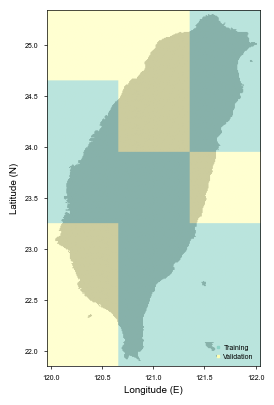

In [49]:
# This cell shows how training/validation data are divided spatially.
# A partition file is read, resized, and visualized on a map.
partition_file='./workspace/partition.txt'
train_val_partitions = np.loadtxt(partition_file, delimiter=',')
train_val_mask = cv2.resize(train_val_partitions, (
    PU.DeepSDM_conf.spatial_conf_tmp['num_of_grid_x'] * PU.DeepSDM_conf.spatial_conf_tmp['grid_size'], 
    PU.DeepSDM_conf.spatial_conf_tmp['num_of_grid_y'] * PU.DeepSDM_conf.spatial_conf_tmp['grid_size']),
    interpolation = cv2.INTER_NEAREST)

fig, ax = plt.subplots(figsize = mm2inch(80, 100), constrained_layout = True)
ax.imshow(
    np.where(PU.extent_binary == 0, np.nan, PU.extent_binary), 
    extent = PU.extent_binary_extent, cmap = ListedColormap('grey')
)
ax.imshow(
    train_val_mask, alpha = 0.6, 
    cmap = ListedColormap(['#ffffb3', '#8dd3c7']), 
    extent = PU.extent_binary_extent
)
ax.set_xlabel('Longitude (E)')
ax.set_ylabel('Latitude (N)')
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))
ax.set_xticks([120, 120.5, 121, 121.5, 122])

validation_proxy = mlines.Line2D([], [], color='#ffffb3', marker='s', linestyle='None', markersize=2, label='Validation')
training_proxy = mlines.Line2D([], [], color='#8dd3c7', marker='s', linestyle='None', markersize=2, label='Training')

ax.legend(handles=[training_proxy, validation_proxy], loc='lower right', handletextpad=-0.2)
plot_output = os.path.join(PU.plot_path_suppl, 'Fig_S2_trainval_split.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

## Fig S3

### **Correlation matrix of environmental variables**

This figure visualizes the **pairwise correlations** among all environmental predictors used in SEAM-SDM.  
A Spearman (or Pearson) correlation matrix was computed and displayed as a heatmap, where the **color scale ranges from –1 (blue) to +1 (red)**.  

Only the **lower triangle** is shown, with numerical correlation values annotated in each cell and thin black borders separating variable pairs.  
Strong positive correlations indicate environmental variables with similar spatial patterns, while negative correlations reveal contrasting gradients.  
The figure helps assess **redundancy and independence** among predictors before model interpretation.


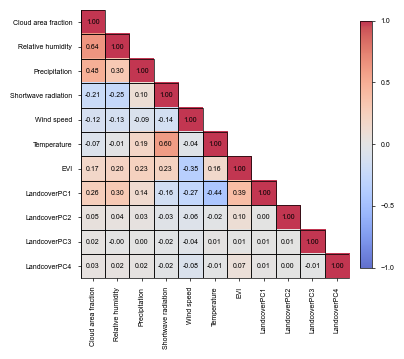

In [50]:
# This cell plots a correlation matrix (Spearman or Pearson) of environmental factors.
# It masks the upper triangle and annotates each cell with correlation values.

# Convert correlation DataFrame to NumPy array for plotting
correlation_array = PU.df_env_corr.to_numpy()
sorted_env_factors = PU.df_env_corr.columns

# Create a mask to hide the upper triangle (k=1 excludes diagonal)
mask = np.triu(np.ones_like(correlation_array, dtype=bool), k=1)
masked_corr = ma.array(correlation_array, mask=mask)

# Define colormap and set masked (upper-triangle) area to white
cmap = plt.cm.coolwarm.copy()
cmap.set_bad(color='white')

# Create heatmap figure
fig, ax = plt.subplots(figsize=mm2inch(100, 100), constrained_layout=True)
cax = ax.imshow(masked_corr, cmap=cmap, interpolation='nearest', vmin=-1, vmax=1, alpha=0.8)

# Add colorbar
cb = fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
cb.ax.tick_params()
cb.ax.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])

# Set axis ticks and labels using detailed variable names
ax.set_xticks(np.arange(len(sorted_env_factors)))
ax.set_yticks(np.arange(len(sorted_env_factors)))
ax.set_xticklabels(convert_to_env_list_detail(sorted_env_factors), rotation=90)
ax.set_yticklabels(convert_to_env_list_detail(sorted_env_factors))

# Annotate lower triangle with correlation values and draw grid rectangles
for i in range(len(sorted_env_factors)):
    for j in range(len(sorted_env_factors)):
        if i >= j:
            # Draw thin cell border
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', linewidth=0.5)
            ax.add_patch(rect)
            # Add correlation text label
            value = correlation_array[i, j]
            ax.text(j, i, f"{value:.2f}", ha='center', va='center', color='black', fontsize=5)

# Clean up plot appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Save the figure as a transparent PDF
plot_output = os.path.join(PU.plot_path_suppl, 'FigS3_env_correlation.pdf')
plt.savefig(plot_output, dpi=500, transparent=True)
plt.show()

## Fig S4

### **Evaluation of niche clustering performance in SEAM-SDM**

This analysis tests how the **DeepSDM-derived species niche spaces** cluster into ecological groups.  
After excluding four species, hierarchical agglomerative clustering was performed using **cosine distance** and **average linkage** across a range of cluster numbers (*K* = 2–20).

Three standard clustering validity metrics were computed:
- **Silhouette Score:** Measures how well species fit within their assigned cluster (higher is better).
- **Calinski–Harabasz Index:** Evaluates cluster compactness and separation (higher indicates clearer structure).

Panels show how **Silhouette** and **Calinski–Harabasz** scores change with cluster number, aiding in the selection of an optimal *K* that balances cohesion and separation in ecological niche space.


Evaluating 20 clusters...

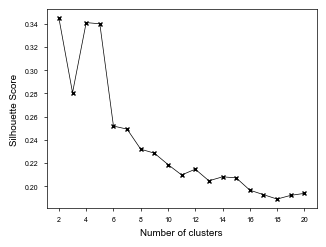

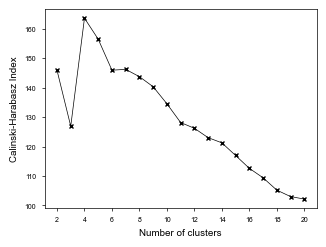

In [12]:
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering

# # Load DeepSDM niche space data for all species, excluding outliers.
# species_list_filter = ['Debregeasia_orientalis', 'Neolitsea_hiiranensis', 'Capparis_micracantha', 'Berberis_mingetsensis', 'Radermachera_sinica', 'Cinnamomum_osmophloeum', 'Cleyera_japonica_var._taipinensis', 'Acer_serrulatum', 'Vaccinium_randaiense', 'Acer_albopurpurascens', 'Polyspora_axillaris', 'Enkianthus_perulatus', 'Machilus_zuihoensis_var._mushaensis', 'Turpinia_formosana', 'Sarcopyramis_napalensis_var._delicata', 'Lithocarpus_harlandii', 'Distyliopsis_dunnii', 'Rubus_formosensis', 'Terminalia_catappa', 'Derris_trifoliata', 'Vernicia_montana', 'Pittosporum_daphniphylloides', 'Trachelospermum_formosanum', 'Macaranga_tanarius', 'Quercus_pachyloma', 'Hydrangea_longifolia', 'Champereia_manillana', 'Dodonaea_viscosa', 'Aeschynanthus_acuminatus', 'Salix_fulvopubescens_var._doii', 'Vernicia_fordii', 'Bombax_ceiba', 'Grewia_rhombifolia', 'Berchemia_lineata', 'Croton_cascarilloides', 'Calocedrus_macrolepis_var._formosana', 'Euonymus_laxiflorus', 'Lepisorus_pseudoussuriensis', 'Actinidia_callosa_var._discolor', 'Crateva_adansonii_subsp._formosensis', 'Vaccinium_kengii', 'Diospyros_oldhamii', 'Castanopsis_eyrei', 'Heptapleurum_heptaphyllum', 'Neolitsea_acuminatissima', 'Ficus_erecta_var._beecheyana', 'Ventilago_leiocarpa', 'Syzygium_densinervium', 'Drypetes_karapinensis', 'Randia_sinensis', 'Lantana_camara', 'Taiwania_cryptomerioides', 'Elaeocarpus_decipiens', 'Ficus_variegata_var._variegata', 'Cayratia_japonica', 'Lagerstroemia_subcostata', 'Ardisia_crenata', 'Triadica_cochinchinensis', 'Kadsura_japonica', 'Albizia_julibrissin', 'Symplocos_koshunensis', 'Nageia_nagi', 'Bretschneidera_sinensis', 'Margaritaria_indica', 'Smilax_bracteata_var._verruculosa', 'Microtropis_japonica', 'Schisandra_arisanensis', 'Euonymus_pallidifolia', 'Oreocnide_pedunculata', 'Ormosia_hengchuniana', 'Aristolochia_kaempferi', 'Osmanthus_matsumuranus', 'Osmanthus_lanceolatus', 'Premna_octonervia', 'Palaquium_formosanum', 'Cinnamomum_insularimontanum', 'Celastrus_kusanoi', 'Syzygium_jambos', 'Hibiscus_syriacus', 'Symplocos_formosana', 'Myrica_adenophora', 'Ficus_subpisocarpa', 'Rubus_kawakamii', 'Camphora_officinarum', 'Actinidia_setosa', 'Zanthoxylum_scandens', 'Lonicera_acuminata', 'Machilus_japonica_var._kusanoi', 'Manihot_esculenta', 'Tetrastigma_bioritsense', 'Ilex_crenata', 'Ilex_tugitakayamensis', 'Styrax_suberifolia', 'Phyllanthus_reticulatus', 'Pistacia_chinensis', 'Cryptomeria_japonica', 'Camellia_oleifera', 'Ardisia_cornudentata_subsp._cornudentata', 'Bridelia_tomentosa', 'Litsea_perrottetii', 'Dimocarpus_longan', 'Mallotus_paniculatus', 'Abies_kawakamii', 'Aucuba_japonica', 'Cleyera_japonica_var._longicarpa', 'Symplocos_caudata', 'Cinnamomum_reticulatum', 'Drypetes_littoralis', 'Stachyurus_himalaicus', 'Juniperus_formosana_var._formosana', 'Cassia_grandis', 'Lasianthus_japonicus', 'Quercus_hypophaea', 'Adinandra_formosana', 'Quercus_gilva', 'Osmanthus_heterophyllus', 'Quercus_longinux', 'Zanthoxylum_pistaciiflorum', 'Callicarpa_tikusikensis', 'Stauntonia_hexaphylla', 'Callicarpa_longissima', 'Heptapleurum_ellipticum', 'Aucuba_chinensis_var._chinensis', 'Parthenocissus_tricuspidata', 'Mallotus_paniculatus_var._formosanus', 'Carpinus_rankanensis', 'Scolopia_oldhamii', 'Broussonetia_papyrifera', 'Lasianthus_bunzanensis', 'Strychnos_cathayensis', 'Cinnamomum_macrostemon', 'Viburnum_plicatum_var._formosanum', 'Bridelia_balansae', 'Rubus_yuliensis', 'Pittosporum_tobira', 'Rhododendron_tashiroi', 'Diospyros_morrisiana', 'Pittosporum_illicioides_var._angustifolium', 'Castanopsis_fargesii', 'Sinopanax_formosanus', 'Actinidia_latifolia', 'Viburnum_urceolatum', 'Melia_azedarach', 'Lindera_aggregata_var._aggregata', 'Leea_philippinensis', 'Fatsia_polycarpa', 'Sambucus_chinensis', 'Phyllanthus_oligospermus', 'Symplocos_congesta_var._theifolia', 'Guettarda_speciosa', 'Tsuga_chinensis_var._formosana', 'Archidendron_lucidum', 'Camellia_japonica', 'Eurycorymbus_cavaleriei', 'Aglaia_elliptifolia', 'Rhododendron_kawakamii', 'Prinsepia_scandens', 'Cinchona_ledgeriana', 'Diospyros_rhombifolia', 'Callicarpa_randaiensis', 'Castanopsis_indica', 'Rhaphiolepis_indica_var._tashiroi', 'Mallotus_japonicus', 'Adinandra_lasiostyla', 'Carpinus_hebestroma', 'Eustigma_oblongifolium', 'Antidesma_japonicum_var._densiflorum', 'Melastoma_candidum', 'Cleyera_japonica_var._japonica', 'Lasianthus_wallichii', 'Aralia_bipinnata', 'Malus_doumeri', 'Euchresta_formosana', 'Aphananthe_aspera', 'Ficus_ampelos', 'Murraya_omphalocarpa', 'Medinilla_formosana', 'Rhododendron_pseudochrysanthum', 'Heptapleurum_taiwanianum', 'Randia_cochinchinensis', 'Photinia_niitakayamensis', 'Litsea_akoensis_var._sasakii', 'Rhododendron_breviperulatum', 'Euonymus_oxyphyllus', 'Koelreuteria_henryi', 'Homalium_cochinchinensis', 'Lithocarpus_glaber', 'Rhamnus_formosana', 'Rhododendron_formosanum', 'Viburnum_erosum', 'Ehretia_resinosa', 'Ardisia_cornudentata_subsp._morrisonensis_var._morrisonensis', 'Rhamnus_nakaharae', 'Pometia_pinnata', 'Stauntonia_obovata', 'Severinia_buxifolia', 'Rhododendron_ovatum_var._lamprophyllum', 'Neolitsea_parvigemma', 'Ficus_esquiroliana', 'Calophyllum_inophyllum', 'Decaspermum_gracilentum', 'Castanopsis_cuspidata_var._carlesii', 'Lithocarpus_kawakamii', 'Symplocos_arisanensis', 'Capparis_floribunda', 'Myrica_rubra', 'Ilex_bioritsensis', 'Vaccinium_wrightii_var._formosanum', 'Ardisia_japonica', 'Machilus_zuihoensis_var._zuihoensis', 'Zanthoxylum_nitidum', 'Tetradium_glabrifolium', 'Syzygium_paucivenium', 'Sycopsis_sinensis', 'Ilex_cochinchinensis', 'Euscaphis_japonica', 'Clerodendrum_canescens', 'Syzygium_buxifolium', 'Boehmeria_densiflora', 'Quercus_repandifolia', 'Premna_microphylla', 'Ficus_ruficaulis_var._antaoensis', 'Illicium_tashiroi', 'Helicia_formosana', 'Viburnum_luzonicum', 'Quercus_sessilifolia', 'Pueraria_montana', 'Lygodium_japonicum', 'Berberis_aristatoserrulata', 'Picrasma_quassioides', 'Photinia_serratifolia_var._ardisiifolia', 'Neolitsea_sericea_var._sericea', 'Astronia_formosana', 'Aralia_finlaysoniana', 'Akebia_longeracemosa', 'Sorbus_randaiensis', 'Berchemia_formosana', 'Neolitsea_buisanensis_fo._buisanensis', 'Arenga_engleri', 'Antidesma_japonicum_var._acutisepalum', 'Melicope_pteleifolia', 'Distylium_gracile', 'Acer_caudatifolium', 'Cunninghamia_lanceolata', 'Photinia_serratifolia_var._serratifolia', 'Elaeagnus_grandifolia', 'Symplocos_nokoensis', 'Ficus_pumila_var._pumila', 'Schizophragma_fauriei', 'Symplocos_cochinchinensis_var._cochinchinensis', 'Euonymus_spraguei', 'Viburnum_taitoense', 'Rhododendron_chilanshanense', 'Quercus_variabilis', 'Pterocarpus_indicus', 'Acer_morrisonense', 'Ilex_lonicerifolia_var._matsudae', 'Itea_parviflora', 'Sabia_swinhoei', 'Blastus_cochinchinensis', 'Alsophila_podophylla', 'Mahonia_japonica', 'Heliotropium_formosanum', 'Rhodomyrtus_tomentosa', 'Cleyera_japonica_var._morii', 'Skimmia_reevesiana', 'Viburnum_formosanum', 'Viburnum_foetidum_var._rectangulatum', 'Phoebe_formosana', 'Heptapleurum_arboricola', 'Leucaena_leucocephala', 'Ficus_fistulosa_fo._benguetensis', 'Embelia_rudis', 'Turpinia_ternata', 'Strobilanthes_longespicatus', 'Paederia_foetida', 'Salix_warburgii', 'Symplocos_trichoclada', 'Acalypha_suirenbiensis', 'Pisonia_umbellifera', 'Camellia_sasanqua', 'Vitex_quinata', 'Acacia_caesia', 'Thespesia_populnea', 'Pourthiaea_beauverdiana_var._notabilis', 'Symplocos_stellaris', 'Erycibe_henryi', 'Prunus_taiwaniana', 'Vaccinium_bracteatum', 'Anneslea_fragrans_var._lanceolata', 'Neolitsea_aciculata_var._variabillima', 'Psidium_guajava', 'Actinidia_rufa', 'Bredia_oldhamii', 'Zanthoxylum_armatum', 'Cornus_kousa', 'Euonymus_carnosus', 'Rhododendron_hyperythrum', 'Viburnum_propinquum', 'Ilex_suzukii', 'Styrax_matsumurae', 'Callicarpa_kochiana', 'Eriobotrya_deflexa', 'Tetrastigma_formosanum', 'Sassafras_randaiense', 'Cornus_macrophylla', 'Tetrastigma_umbellatum', 'Diospyros_japonica', 'Wendlandia_uvariifolia', 'Picea_morrisonicola', 'Urceola_rosea', 'Meliosma_rigida', 'Neolitsea_konishii', 'Deutzia_pulchra', 'Rhamnus_crenata', 'Glochidion_philippicum', 'Ficus_septica', 'Strobilanthes_formosanus', 'Prunus_zippeliana', 'Castanopsis_formosana', 'Vitex_negundo', 'Lithocarpus_corneus', 'Symplocos_modesta', 'Smilax_bracteata_var._bracteata', 'Lithocarpus_amygdalifolius', 'Eurya_strigillosa', 'Deutzia_taiwanensis', 'Millettia_pachycarpa', 'Callicarpa_pilosissima', 'Nageia_fleuryi', 'Lithocarpus_nantoensis', 'Ilex_pubescens', 'Piper_kadsura', 'Vaccinium_merrillianum', 'Gymnema_sylvestre', 'Osmanthus_enervius', 'Castanopsis_fabri', 'Garcinia_multiflora', 'Flueggea_suffruticosa', 'Ventilago_elegans', 'Symplocos_setchuensis', 'Buxus_microphylla_subsp._sinica', 'Aglaia_formosana', 'Vaccinium_japonicum_var._lasiostemon', 'Illicium_arborescens', 'Machilus_obovatifolia', 'Berberis_kawakamii', 'Callicarpa_remotiserrulata', 'Engelhardia_roxburghiana', 'Callicarpa_formosana_var._glabrata', 'Ficus_microcarpa_var._crassifolia', 'Clematis_tashiroi', 'Cordia_aspera', 'Tarenna_gracilipes', 'Meliosma_squamulata', 'Trachelospermum_gracilipes', 'Zelkova_serrata', 'Lasianthus_curtisii', 'Rhaphiolepis_indica_var._hiiranensis', 'Glochidion_zeylanicum_var._zeylanicum', 'Lasianthus_appressihirtus_var._appressihirtus', 'Calamus_beccarii', 'Alsophila_loheri', 'Lithocarpus_lepidocarpus', 'Quercus_globosa', 'Styrax_formosana', 'Diplospora_dubia', 'Sageretia_thea', 'Lasianthus_appressihirtus_var._maximus', 'Symplocos_grandis', 'Vaccinium_emarginatum', 'Sinoadina_racemosa', 'Machilus_pseudolongifolia', 'Toddalia_asiatica', 'Zanthoxylum_schinifolium', 'Rhus_succedanea_var._succedanea', 'Breynia_officinalis_var._officinalis', 'Ficus_punctata', 'Camphora_kanahirae', 'Rhamnus_parvifolia', 'Berberis_morrisonensis', 'Reevesia_formosana', 'Cryptocarya_concinna', 'Ficus_tinctoria', 'Alnus_formosana', 'Machilus_thunbergii', 'Berchemia_racemosa_var._magna', 'Calamus_formosanus', 'Melicope_semecarpifolia', 'Litsea_cubeba', 'Quercus_glauca', 'Dysoxylum_hongkongense', 'Boehmeria_nivea_var._tenacissima', 'Ficus_microcarpa_var._microcarpa', 'Diospyros_philippensis', 'Sphaeropteris_lepifera', 'Lindera_communis', 'Viburnum_integrifolium', 'Viburnum_odoratissimum', 'Malus_hupehensis', 'Sageretia_randaiensis', 'Magnolia_compressa_var._formosana', 'Erythrina_variegata', 'Pittosporum_pentandrum', 'Pourthiaea_villosa_var._parvifolia', 'Eurya_loquaiana', 'Beilschmiedia_erythrophloia', 'Quercus_salicina', 'Camellia_furfuracea', 'Schima_superba_var._kankaoensis', 'Ulmus_parvifolia', 'Fraxinus_insularis', 'Clematis_henryi_var._morii', 'Lasianthus_biflorus', 'Rhamnus_pilushanensis', 'Litsea_acutivena', 'Euonymus_tashiroi', 'Schoepfia_jasminodora', 'Ilex_uraiensis', 'Quercus_tatakaensis', 'Litsea_morrisonensis', 'Smilax_china', 'Jasminum_sinense', 'Medinilla_taiwaniana', 'Camellia_transarisanensis', 'Ehretia_acuminata', 'Ulmus_uyematsui', 'Lithocarpus_synbalanos', 'Ficus_caulocarpa', 'Castanopsis_kawakamii', 'Alsophila_spinulosa', 'Paulownia_fortunei', 'Gaultheria_cumingiana', 'Ilex_sugerokii_var._brevipedunculata', 'Styrax_hayataianus', 'Bauhinia_variegata', 'Prunus_transarisanensis_var._takasagomontana', 'Symplocos_chinensis', 'Syzygium_kusukusense', 'Buxus_liukiuensis', 'Pouzolzia_elegans', 'Celtis_sinensis', 'Citrus_reticulata_var._depressa', 'Elaeocarpus_japonicus', 'Pentapanax_castanopsidicola', 'Phellodendron_amurense_var._wilsonii', 'Trichodesma_calycosum', 'Cinnamomum_brevipedunculatum', 'Spiraea_thunbergii', 'Lasianthus_fordii', 'Chamaecyparis_obtusa_var._formosana', 'Neolitsea_aciculata_var._aciculata', 'Clematis_uncinata_var._uncinata', 'Rhododendron_rubropunctatum', 'Neonauclea_reticulata', 'Miscanthus_floridulus', 'Ilex_ficoidea', 'Symplocos_heishanensis', 'Prunus_obtusata', 'Camphora_micrantha', 'Anodendron_affine', 'Celtis_biondii', 'Pandanus_odorifer', 'Eurya_acuminata', 'Nekemias_cantoniensis', 'Artocarpus_treculianus', 'Hydrangea_angustipetala', 'Pileostegia_viburnoides', 'Sarcandra_glabra', 'Brucea_javanica', 'Glochidion_zeylanicum_var._lanceolatum', 'Hydrangea_anomala', 'Callicarpa_hypoleucophylla', 'Citrus_maxima', 'Damnacanthus_angustifolius', 'Ampelopsis_brevipedunculata_var._hancei', 'Leea_guineensis', 'Fissistigma_glaucescens', 'Xylosma_congesta', 'Liquidambar_formosana', 'Camellia_caudata', 'Pittosporum_illicioides_var._illicioides', 'Quercus_longinux_var._kuoi', 'Maytenus_diversifolia', 'Ilex_arisanensis', 'Microlepia_×_bipinnata', 'Magnolia_kachirachirai', 'Photinia_lucida', 'Eurya_hayatae', 'Symplocos_congesta_var._congesta', 'Celastrus_hindsii', 'Ardisia_sieboldii', 'Chrinephrium_insulare', 'Firmiana_simplex', 'Litsea_acuminata', 'Rhus_sylvestris', 'Smilax_planipedunculata', 'Premna_serratifolia', 'Cephalotaxus_wilsoniana', 'Prunus_matuurae', 'Hydrangea_paniculata', 'Ilex_maximowicziana', 'Juglans_cathayensis', 'Amentotaxus_formosana', 'Symplocos_sonoharae_var._sonoharae', 'Tetradium_ruticarpum', 'Castanopsis_cuspidata_fo._sessilis', 'Magnolia_compressa_var._compressa', 'Ilex_goshiensis', 'Strobilanthes_flexicaulis', 'Celtis_nervosa', 'Symplocos_theophrastifolia', 'Cunninghamia_konishii', 'Prunus_spinulosa', 'Eurya_crenatifolia', 'Cinnamomum_subavenium', 'Stephanandra_incisa', 'Capparis_sikkimensis_subsp._formosana', 'Camellia_transnokoensis', 'Epipremnum_pinnatum', 'Derris_laxiflora', 'Clausena_excavata', 'Daphne_arisanensis', 'Pinus_armandii_var._mastersiana', 'Antidesma_hiiranense', 'Citrus_×_taiwanica', 'Ehretia_longiflora', 'Ilex_yunnanensis', 'Callicarpa_dichotoma', 'Glycosmis_citrifolia', 'Ilex_formosana', 'Camellia_formosensis', 'Citrus_tachibana', 'Smilax_corbularia', 'Skimmia_arisanensis', 'Casearia_membranacea', 'Osmanthus_marginatus', 'Zanthoxylum_avicennae', 'Celastrus_punctatus', 'Dendrocalamus_latiflorus', 'Alniphyllum_pterospermum', 'Podocarpus_fasciculus', 'Blumea_lacera', 'Gaultheria_itoana', 'Amischotolype_hispida', 'Mucuna_macrocarpa', 'Photinia_serratifolia_var._lasiopetala', 'Sloanea_formosana', 'Eurya_chinensis', 'Maesa_japonica', 'Murraya_euchrestifolia', 'Pongamia_pinnata', 'Rhododendron_rubropilosum_var._rubropilosum', 'Podocarpus_macrophyllus_var._maki', 'Acalypha_matudae', 'Daphniphyllum_glaucescens_subsp._oldhamii', 'Melanolepis_multiglandulosa', 'Machilus_konishii', 'Viburnum_parvifolium', 'Myrsine_seguinii', 'Salix_fulvopubescens_var._fulvopubescens', 'Hymenophyllum_fujisanense', 'Quercus_championii', 'Falcataria_falcata', 'Trema_orientalis', 'Abelia_chinensis_var._ionandra', 'Helicia_rengetiensis', 'Mallotus_repandus', 'Camellia_nokoensis', 'Callerya_nitida_var._nitida', 'Barthea_barthei', 'Mahonia_oiwakensis', 'Callicarpa_remotiflora', 'Tarenna_zeylanica', 'Lithocarpus_dodonaeifolius', 'Dalbergia_benthamii', 'Syzygium_euphlebium', 'Hydrangea_chinensis', 'Celtis_tetrandra', 'Mussaenda_pubescens', 'Symplocos_migoi', 'Psychotria_serpens', 'Strobilanthes_cusia', 'Aralia_decaisneana', 'Symplocos_glauca', 'Pyrenaria_shinkoensis', 'Hibiscus_taiwanensis', 'Fissistigma_oldhamii', 'Distylium_racemosum', 'Pueraria_montana_var._lobata', 'Castanopsis_uraiana', 'Glochidion_rubrum', 'Rhododendron_ovatum_var._ovatum', 'Platycarya_strobilacea', 'Prunus_buergeriana', 'Alangium_chinense', 'Machilus_philippinensis', 'Marsdenia_formosana', 'Bredia_gibba', 'Pilea_aquarum_subsp._brevicornuta', 'Ficus_formosana_fo._formosana', 'Rubus_mesogaeus', 'Wikstroemia_lanceolata', 'Ilex_lonicerifolia_var._lonicerifolia', 'Hibiscus_tiliaceus', 'Tetrapanax_papyriferus', 'Lasianthus_cyanocarpus', 'Hiptage_benghalensis', 'Piper_sintenense', 'Quercus_tarokoensis', 'Eurya_nitida_var._nitida', 'Embelia_lenticellata', 'Barringtonia_asiatica', 'Rhamnus_chingshuiensis_var._tashanensis', 'Lasianthus_chinensis', 'Litsea_coreana', 'Phanera_championii', 'Eurya_leptophylla', 'Maclura_cochinchinensis', 'Diospyros_eriantha', 'Elaeagnus_glabra', 'Ficus_virgata', 'Claoxylon_brachyandrum', 'Deutzia_cordatula', 'Wikstroemia_indica', 'Triadica_sebifera', 'Ficus_nervosa', 'Ligustrum_liukiuense', 'Lindera_akoensis', 'Meliosma_callicarpifolia', 'Daphniphyllum_membranaceum', 'Lithocarpus_shinsuiensis', 'Quercus_spinosa', 'Embelia_laeta_var._papilligera', 'Podocarpus_nakaii', 'Meliosma_rhoifolia', 'Christella_parasitica', 'Strobilanthes_rankanensis', 'Prunus_transarisanensis', 'Eurya_glaberrima', 'Helicia_cochinchinensis', 'Saurauia_oldhamii', 'Lasianthus_obliquinervis_var._obliquinervis', 'Hydrangea_aspera', 'Symplocos_shilanensis', 'Viburnum_arboricolum', 'Prunus_phaeosticta_var._ilicifolia', 'Rubus_pyrifolius', 'Derris_elliptica', 'Ailanthus_altissima_var._tanakai', 'Glochidion_acuminatum', 'Hernandia_nymphiifolia', 'Actinidia_arguta', 'Fraxinus_griffithii', 'Spiraea_prunifolia', 'Dendrocnide_meyeniana', 'Eurya_gnaphalocarpa', 'Camellia_assamica', 'Premna_odorata', 'Musa_basjoo_var._formosana', 'Lindera_megaphylla', 'Broussonetia_monoica', 'Litsea_lii_var._lii', 'Itea_oldhamii', 'Coriaria_japonica_subsp._intermedia', 'Fagus_hayatae', 'Symplocos_sasakii', 'Ligustrum_sinense', 'Bischofia_javanica', 'Ternstroemia_gymnanthera', 'Callicarpa_formosana_var._longifolia', 'Ardisia_cornudentata_subsp._morrisonensis_var._stenosepala', 'Idesia_polycarpa', 'Gardenia_jasminoides', 'Cornus_controversa', 'Ilex_micrococca', 'Rhus_ambigua', 'Podocarpus_macrophyllus_var._macrophyllus', 'Embelia_laeta', 'Camellia_brevistyla', 'Litsea_hypophaea', 'Schima_superba_var._superba', 'Anodendron_benthamianum', 'Wendlandia_formosana', 'Rhaphiolepis_indica_var._umbellata', 'Wisteriopsis_reticulata_var._reticulata', 'Yushania_niitakayamensis', 'Trochodendron_aralioides', 'Ficus_irisana', 'Ficus_benjamina', 'Lyonia_ovalifolia_var._ovalifolia', 'Morus_australis', 'Mallotus_philippensis', 'Sabia_transarisanensis', 'Castanopsis_kusanoi', 'Acer_palmatum_var._pubescens', 'Lindera_erythrocarpa', 'Ormosia_formosana', 'Elaeagnus_formosana', 'Rhododendron_noriakianum', 'Lasianthus_microstachys', 'Freycinetia_formosana', 'Quercus_stenophylloides', 'Microtropis_fokienensis', 'Damnacanthus_indicus', 'Litchi_chinensis', 'Annona_squamosa', 'Acacia_confusa', 'Camellia_salicifolia', 'Prunus_phaeosticta_var._phaeosticta', 'Maesa_perlaria_var._formosana', 'Cinchona_succirubra', 'Beilschmiedia_tsangii', 'Litsea_akoensis_var._akoensis', 'Pieris_taiwanensis', 'Zanthoxylum_ailanthoides', 'Prunus_campanulata', 'Carpinus_kawakamii', 'Osmanthus_kaoi', 'Brugmansia_suaveolens', 'Wikstroemia_taiwanensis', 'Clerodendrum_trichotomum', 'Litsea_elongata_var._mushaensis', 'Rubus_swinhoei_var._swinhoei', 'Cotoneaster_konishii', 'Illicium_anisatum', 'Ribes_formosanum', 'Phoenix_hanceana', 'Dendropanax_dentiger', 'Smilax_lanceifolia', 'Allophylus_timorensis', 'Lasianthus_microphyllus', 'Lithocarpus_konishii', 'Rhododendron_oldhamii', 'Hydrangea_integrifolia', 'Sapindus_mukorossi', 'Rhododendron_ellipticum', 'Ardisia_virens', 'Buchanania_arborescens', 'Psychotria_rubra', 'Rhododendron_mariesii', 'Malaisia_scandens', 'Daphne_kiusiana_var._atrocaulis', 'Lindera_glauca', 'Cymbidium_lancifolium_var._aspidistrifolium', 'Ficus_fistulosa_fo._fistulosa', 'Litsea_rotundifolia_var._oblongifolia', 'Ehretia_dicksonii', 'Clematis_grata', 'Lithocarpus_hancei', 'Deparia_jiulungensis', 'Ilex_hayataiana', 'Hedera_rhombea_var._formosana', 'Helwingia_japonica_subsp._taiwaniana', 'Boehmeria_wattersii', 'Symplocos_wikstroemiifolia', 'Liodendron_formosanum', 'Neolitsea_daibuensis', 'Syzygium_formosanum', 'Cryptocarya_chinensis', 'Randia_canthioides', 'Kleinhovia_hospita', 'Ficus_sarmentosa_var._nipponica', 'Bredia_hirsuta_var._scandens', 'Pinus_taiwanensis', 'Viburnum_sympodiale', 'Ardisia_quinquegona', 'Pinus_morrisonicola', 'Pisonia_aculeata', 'Ilex_rotunda', 'Juniperus_squamata', 'Viburnum_betulifolium', 'Antidesma_pentandrum_var._barbatum', 'Uncaria_hirsuta', 'Rhus_javanica_var._roxburghiana', 'Murraya_paniculata', 'Symplocos_acuminata', 'Perrottetia_arisanensis', 'Taxus_sumatrana', 'Grewia_biloba', 'Ilex_asprella', 'Symplocos_eriostroma', 'Akebia_trifoliata_subsp._australis', 'Symplocos_konishii', 'Callicarpa_formosana_var._formosana', 'Litsea_lii_var._nunkao-tahangensis', 'Ligustrum_pricei', 'Ligustrum_morrisonense', 'Clerodendrum_cyrtophyllum', 'Chamaecyparis_formosensis', 'Lasianthus_formosensis', 'Vaccinium_wrightii_var._wrightii', 'Gleditsia_rolfei', 'Cinnamomum_austrosinense', 'Elaeagnus_thunbergii', 'Ilex_pedunculosa', 'Planchonella_obovata', 'Eleutherococcus_trifoliatus_var._trifoliatus', 'Capparis_acutifolia', 'Smilax_menispermoidea', 'Timonius_arboreus', 'Mangifera_indica', 'Symplocos_morrisonicola', 'Pseudotsuga_wilsoniana']
# species_list_exclude = list(set(PU.species_list_predict) - set(species_list_filter))
# 20260508 ADD
# Trees with occurrence records more than 90% percentile among all species
species_list_prediect_percentile80 = ['Abies_kawakamii', 'Acacia_confusa', 'Acer_albopurpurascens', 'Acer_caudatifolium', 'Acer_morrisonense', 'Acer_serrulatum', 'Adinandra_formosana', 'Adinandra_lasiostyla', 'Aeschynanthus_acuminatus', 'Aglaia_elliptifolia', 'Aglaia_formosana', 'Ainsliaea_latifolia', 'Alnus_formosana', 'Alocasia_odora', 'Alpinia_intermedia', 'Alpinia_shimadae_var._shimadae', 'Alpinia_zerumbet', 'Alsophila_podophylla', 'Alsophila_spinulosa', 'Amischotolype_hispida', 'Angiopteris_lygodiifolia', 'Antidesma_hiiranense', 'Antidesma_japonicum_var._densiflorum', 'Arachniodes_amabilis_var._fimbriata', 'Arachniodes_aristata', 'Arachniodes_festina', 'Arachniodes_pseudoaristata', 'Archidendron_lucidum', 'Ardisia_cornudentata_subsp._cornudentata', 'Ardisia_cornudentata_subsp._morrisonensis_var._morrisonensis', 'Ardisia_crenata', 'Ardisia_quinquegona', 'Ardisia_sieboldii', 'Ardisia_virens', 'Arenga_engleri', 'Asarum_macranthum', 'Asplenium_antiquum', 'Asplenium_nidus', 'Asplenium_normale_fo._normale', 'Asplenium_pseudolaserpitiifolium', 'Asplenium_setoi', 'Asplenium_wilfordii_var._wilfordii', 'Athyrium_arisanense', 'Aucuba_chinensis_var._chinensis', 'Aucuba_japonica', 'Barthea_barthei', 'Begonia_formosana', 'Begonia_palmata', 'Beilschmiedia_erythrophloia', 'Beilschmiedia_tsangii', 'Berberis_kawakamii', 'Berberis_morrisonensis', 'Bischofia_javanica', 'Blastus_cochinchinensis', 'Blechnopsis_orientalis', 'Boehmeria_densiflora', 'Boehmeria_wattersii', 'Bridelia_balansae', 'Bridelia_tomentosa', 'Broussonetia_papyrifera', 'Calamus_formosanus', 'Callicarpa_dichotoma', 'Callicarpa_formosana_var._formosana', 'Callicarpa_randaiensis', 'Callicarpa_remotiserrulata', 'Camellia_brevistyla', 'Camellia_caudata', 'Camellia_formosensis', 'Camellia_transnokoensis', 'Camphora_officinarum', 'Carex_brunnea', 'Carex_cruciata', 'Carpinus_kawakamii', 'Castanopsis_cuspidata_fo._sessilis', 'Castanopsis_cuspidata_var._carlesii', 'Castanopsis_fabri', 'Castanopsis_fargesii', 'Castanopsis_formosana', 'Castanopsis_indica', 'Castanopsis_kawakamii', 'Castanopsis_kusanoi', 'Cayratia_japonica', 'Celtis_sinensis', 'Celtis_tetrandra', 'Cephalantheropsis_obcordata_var._obcordata', 'Chamaecyparis_formosensis', 'Chamaecyparis_obtusa_var._formosana', 'Champereia_manillana', 'Chloranthus_oldhamii', 'Christella_parasitica', 'Cinnamomum_insularimontanum', 'Cinnamomum_macrostemon', 'Cinnamomum_osmophloeum', 'Cinnamomum_reticulatum', 'Cinnamomum_subavenium', 'Clerodendrum_cyrtophyllum', 'Clerodendrum_trichotomum', 'Cleyera_japonica_var._japonica', 'Cleyera_japonica_var._morii', 'Cleyera_japonica_var._taipinensis', 'Codonacanthus_pauciflorus', 'Coniogramme_intermedia', 'Croton_cascarilloides', 'Cryptocarya_chinensis', 'Cryptocarya_concinna', 'Ctenitis_subglandulosa', 'Cyclosorus_interruptus', 'Damnacanthus_angustifolius', 'Damnacanthus_indicus', 'Daphniphyllum_glaucescens_subsp._oldhamii', 'Daphniphyllum_membranaceum', 'Davallia_clarkei', 'Davallia_trichomanoides', 'Dendrocnide_meyeniana', 'Dendropanax_dentiger', 'Derris_laxiflora', 'Deschampsia_flexuosa', 'Deutzia_pulchra', 'Dicranopteris_linearis_var._linearis', 'Dimocarpus_longan', 'Diospyros_eriantha', 'Diospyros_morrisiana', 'Diospyros_philippensis', 'Diplazium_dilatatum', 'Diplazium_doederleinii', 'Diplazium_donianum_var._donianum', 'Diplazium_kawakamii', 'Diplazium_laxifrons', 'Diplospora_dubia', 'Drynaria_coronans', 'Dryopteris_formosana', 'Dryopteris_lepidopoda', 'Dryopteris_paleolata', 'Dryopteris_scottii', 'Dryopteris_sordidipes', 'Dryopteris_sparsa', 'Dryopteris_varia', 'Drypetes_karapinensis', 'Dysoxylum_hongkongense', 'Ehretia_resinosa', 'Elaeagnus_glabra', 'Elaeagnus_thunbergii', 'Elaeocarpus_decipiens', 'Elaeocarpus_japonicus', 'Elatostema_lineolatum_var._majus', 'Elatostema_platyphylloides', 'Elatostema_trilobulatum', 'Eleutherococcus_trifoliatus_var._trifoliatus', 'Embelia_laeta', 'Embelia_laeta_var._papilligera', 'Engelhardia_roxburghiana', 'Epipremnum_pinnatum', 'Eriobotrya_deflexa', 'Erycibe_henryi', 'Euonymus_laxiflorus', 'Euonymus_spraguei', 'Euonymus_tashiroi', 'Eurya_acuminata', 'Eurya_chinensis', 'Eurya_crenatifolia', 'Eurya_glaberrima', 'Eurya_hayatae', 'Eurya_leptophylla', 'Eurya_loquaiana', 'Eurya_nitida_var._nitida', 'Eurya_strigillosa', 'Eustigma_oblongifolium', 'Fagus_hayatae', 'Fatsia_polycarpa', 'Festuca_ovina', 'Ficus_benjamina', 'Ficus_erecta_var._beecheyana', 'Ficus_fistulosa_fo._fistulosa', 'Ficus_formosana_fo._formosana', 'Ficus_irisana', 'Ficus_microcarpa_var._microcarpa', 'Ficus_sarmentosa_var._nipponica', 'Ficus_septica', 'Ficus_virgata', 'Fraxinus_griffithii', 'Gardenia_jasminoides', 'Gaultheria_itoana', 'Glochidion_acuminatum', 'Glochidion_rubrum', 'Glycosmis_citrifolia', 'Gomphostemma_callicarpoides', 'Goniophlebium_amoenum', 'Goniophlebium_argutum', 'Goniophlebium_formosanum', 'Goodyera_similis', 'Gynostemma_pentaphyllum', 'Haplopteris_flexuosa', 'Hedera_rhombea_var._formosana', 'Helicia_cochinchinensis', 'Helicia_formosana', 'Helicia_rengetiensis', 'Helwingia_japonica_subsp._taiwaniana', 'Hemiboea_bicornuta', 'Heptapleurum_heptaphyllum', 'Heptapleurum_taiwanianum', 'Hoya_carnosa', 'Hydrangea_angustipetala', 'Hydrangea_chinensis', 'Hydrangea_integrifolia', 'Hylodesmum_laterale', 'Hymenophyllum_fujisanense', 'Ilex_asprella', 'Ilex_bioritsensis', 'Ilex_cochinchinensis', 'Ilex_ficoidea', 'Ilex_formosana', 'Ilex_goshiensis', 'Ilex_hayataiana', 'Ilex_maximowicziana', 'Ilex_rotunda', 'Ilex_sugerokii_var._brevipedunculata', 'Ilex_tugitakayamensis', 'Ilex_uraiensis', 'Ilex_yunnanensis', 'Illicium_anisatum', 'Illicium_arborescens', 'Itea_oldhamii', 'Itea_parviflora', 'Juniperus_formosana_var._formosana', 'Juniperus_squamata', 'Lagerstroemia_subcostata', 'Lasianthus_bunzanensis', 'Lasianthus_fordii', 'Lasianthus_microphyllus', 'Lasianthus_microstachys', 'Lasianthus_obliquinervis_var._obliquinervis', 'Lasianthus_wallichii', 'Lemmaphyllum_microphyllum', 'Lemmaphyllum_rostratum', 'Lepisorus_monilisorus', 'Lepisorus_obscurevenulosus', 'Lepisorus_thunbergianus', 'Leptochilus_ellipticus', 'Leptochilus_wrightii', 'Ligustrum_liukiuense', 'Ligustrum_pricei', 'Ligustrum_sinense', 'Lindera_communis', 'Lindera_megaphylla', 'Liquidambar_formosana', 'Liriope_minor_var._angustissima', 'Liriope_spicata', 'Lithocarpus_amygdalifolius', 'Lithocarpus_corneus', 'Lithocarpus_dodonaeifolius', 'Lithocarpus_glaber', 'Lithocarpus_hancei', 'Lithocarpus_harlandii', 'Lithocarpus_kawakamii', 'Lithocarpus_konishii', 'Lithocarpus_lepidocarpus', 'Lithocarpus_synbalanos', 'Litsea_acuminata', 'Litsea_acutivena', 'Litsea_akoensis_var._akoensis', 'Litsea_elongata_var._mushaensis', 'Litsea_hypophaea', 'Litsea_lii_var._lii', 'Litsea_lii_var._nunkao-tahangensis', 'Litsea_morrisonensis', 'Lonicera_acuminata', 'Lophatherum_gracile', 'Luzula_taiwaniana', 'Lycopodium_clavatum', 'Lygodium_japonicum', 'Lyonia_ovalifolia_var._ovalifolia', 'Lysionotus_pauciflorus_var._pauciflorus', 'Macaranga_tanarius', 'Machilus_japonica_var._kusanoi', 'Machilus_konishii', 'Machilus_obovatifolia', 'Machilus_pseudolongifolia', 'Machilus_thunbergii', 'Machilus_zuihoensis_var._mushaensis', 'Machilus_zuihoensis_var._zuihoensis', 'Maclura_cochinchinensis', 'Maesa_japonica', 'Maesa_perlaria_var._formosana', 'Magnolia_compressa_var._compressa', 'Magnolia_kachirachirai', 'Mahonia_oiwakensis', 'Mallotus_japonicus', 'Mallotus_paniculatus', 'Mallotus_philippensis', 'Malus_doumeri', 'Marsdenia_formosana', 'Melanolepis_multiglandulosa', 'Melastoma_candidum', 'Melicope_pteleifolia', 'Meliosma_callicarpifolia', 'Meliosma_rhoifolia', 'Meliosma_rigida', 'Meliosma_squamulata', 'Microlepia_strigosa', 'Micropolypodium_okuboi', 'Microtropis_fokienensis', 'Miscanthus_floridulus', 'Miscanthus_sinensis', 'Monachosorum_henryi', 'Morus_australis', 'Mucuna_macrocarpa', 'Murraya_euchrestifolia', 'Murraya_paniculata', 'Mussaenda_pubescens', 'Myrica_rubra', 'Myrsine_seguinii', 'Myrsine_stolonifera', 'Neolepisorus_fortunei', 'Neolitsea_aciculata_var._aciculata', 'Neolitsea_aciculata_var._variabillima', 'Neolitsea_acuminatissima', 'Neolitsea_daibuensis', 'Neolitsea_konishii', 'Neolitsea_parvigemma', 'Nephrolepis_biserrata', 'Nephrolepis_cordifolia', 'Ophiopogon_intermedius', 'Ophiopogon_reversus', 'Ophiorrhiza_japonica', 'Oplismenus_compositus', 'Oplismenus_undulatifolius_var._undulatifolius', 'Oreocnide_pedunculata', 'Ormosia_formosana', 'Osmanthus_enervius', 'Osmanthus_heterophyllus', 'Osmanthus_lanceolatus', 'Osmanthus_marginatus', 'Osmanthus_matsumuranus', 'Oxalis_acetosella_subsp._griffithii_var._formosana', 'Passiflora_suberosa', 'Pellionia_radicans', 'Peperomia_tetraphylla', 'Pericampylus_formosanus', 'Persicaria_chinensis', 'Phanera_championii', 'Phoebe_formosana', 'Photinia_lucida', 'Photinia_niitakayamensis', 'Picea_morrisonicola', 'Pieris_taiwanensis', 'Pilea_aquarum_subsp._brevicornuta', 'Pilea_funkikensis', 'Pilea_plataniflora', 'Pileostegia_viburnoides', 'Pinus_armandii_var._mastersiana', 'Pinus_morrisonicola', 'Pinus_taiwanensis', 'Piper_kadsura', 'Piper_sintenense', 'Pittosporum_illicioides_var._illicioides', 'Pittosporum_pentandrum', 'Plagiogyria_adnata', 'Plagiogyria_euphlebia', 'Plagiogyria_falcata', 'Plagiogyria_glauca', 'Plagiogyria_stenoptera', 'Platycarya_strobilacea', 'Pollia_miranda', 'Polyspora_axillaris', 'Polystichum_hancockii', 'Polystichum_parvipinnulum', 'Pothos_chinensis', 'Pourthiaea_beauverdiana_var._notabilis', 'Pourthiaea_villosa_var._parvifolia', 'Procris_laevigata', 'Prunus_campanulata', 'Prunus_phaeosticta_var._ilicifolia', 'Prunus_phaeosticta_var._phaeosticta', 'Prunus_spinulosa', 'Pseudotsuga_wilsoniana', 'Psychotria_rubra', 'Psychotria_serpens', 'Pteris_setulosocostulata', 'Pyrenaria_shinkoensis', 'Pyrrosia_lingua', 'Pyrrosia_sheareri', 'Quercus_gilva', 'Quercus_glauca', 'Quercus_longinux', 'Quercus_pachyloma', 'Quercus_repandifolia', 'Quercus_sessilifolia', 'Quercus_spinosa', 'Quercus_stenophylloides', 'Quercus_tarokoensis', 'Quercus_tatakaensis', 'Quercus_variabilis', 'Randia_cochinchinensis', 'Rhaphiolepis_indica_var._tashiroi', 'Rhododendron_breviperulatum', 'Rhododendron_ellipticum', 'Rhododendron_formosanum', 'Rhododendron_hyperythrum', 'Rhododendron_mariesii', 'Rhododendron_oldhamii', 'Rhododendron_pseudochrysanthum', 'Rhododendron_rubropilosum_var._rubropilosum', 'Rhus_succedanea_var._succedanea', 'Rubus_corchorifolius', 'Rubus_formosensis', 'Rubus_kawakamii', 'Rubus_pectinellus', 'Rubus_swinhoei_var._swinhoei', 'Sapindus_mukorossi', 'Sarcandra_glabra', 'Sarcopyramis_napalensis_var._bodinieri', 'Sarcopyramis_napalensis_var._delicata', 'Saurauia_oldhamii', 'Schima_superba_var._kankaoensis', 'Schima_superba_var._superba', 'Schizophragma_fauriei', 'Selaginella_delicatula', 'Selaginella_doederleinii_subsp._doederleinii', 'Selaginella_involvens', 'Selaginella_moellendorffii', 'Selliguea_lehmannii', 'Severinia_buxifolia', 'Sinoadina_racemosa', 'Skimmia_reevesiana', 'Sloanea_formosana', 'Smilax_arisanensis', 'Smilax_bracteata_var._bracteata', 'Smilax_bracteata_var._verruculosa', 'Smilax_china', 'Smilax_lanceifolia', 'Smilax_planipedunculata', 'Smilax_riparia', 'Solidago_virgaurea_var._leiocarpa', 'Sphaeropteris_lepifera', 'Spiraea_thunbergii', 'Stachyurus_himalaicus', 'Stauntonia_hexaphylla', 'Strobilanthes_cusia', 'Strobilanthes_flexicaulis', 'Strobilanthes_longespicatus', 'Strobilanthes_rankanensis', 'Styrax_formosana', 'Styrax_suberifolia', 'Sycopsis_sinensis', 'Symplocos_arisanensis', 'Symplocos_caudata', 'Symplocos_congesta_var._congesta', 'Symplocos_congesta_var._theifolia', 'Symplocos_formosana', 'Symplocos_glauca', 'Symplocos_heishanensis', 'Symplocos_konishii', 'Symplocos_migoi', 'Symplocos_modesta', 'Symplocos_morrisonicola', 'Symplocos_stellaris', 'Symplocos_theophrastifolia', 'Symplocos_wikstroemiifolia', 'Syzygium_buxifolium', 'Syzygium_euphlebium', 'Syzygium_formosanum', 'Syzygium_kusukusense', 'Tarenna_gracilipes', 'Ternstroemia_gymnanthera', 'Tetradium_glabrifolium', 'Tetrastigma_bioritsense', 'Tetrastigma_formosanum', 'Tetrastigma_umbellatum', 'Trachelospermum_gracilipes', 'Trachelospermum_jasminoides', 'Trema_orientalis', 'Tricholepidium_buergerianum', 'Trochodendron_aralioides', 'Tsuga_chinensis_var._formosana', 'Turpinia_formosana', 'Turpinia_ternata', 'Urceola_rosea', 'Vaccinium_bracteatum', 'Vaccinium_emarginatum', 'Vaccinium_japonicum_var._lasiostemon', 'Vaccinium_randaiense', 'Vaccinium_wrightii_var._wrightii', 'Vandenboschia_auriculata', 'Viburnum_arboricolum', 'Viburnum_betulifolium', 'Viburnum_erosum', 'Viburnum_foetidum_var._rectangulatum', 'Viburnum_formosanum', 'Viburnum_integrifolium', 'Viburnum_luzonicum', 'Viburnum_odoratissimum', 'Viburnum_parvifolium', 'Viburnum_propinquum', 'Viburnum_sympodiale', 'Viburnum_taitoense', 'Viburnum_urceolatum', 'Wendlandia_formosana', 'Wendlandia_uvariifolia', 'Yushania_niitakayamensis', 'Zanthoxylum_nitidum', 'Zanthoxylum_scandens', 'Zelkova_serrata', 'Zingiber_pleiostachyum']
species_list_tree = ['Debregeasia_orientalis', 'Neolitsea_hiiranensis', 'Capparis_micracantha', 'Berberis_mingetsensis', 'Radermachera_sinica', 'Cinnamomum_osmophloeum', 'Cleyera_japonica_var._taipinensis', 'Acer_serrulatum', 'Vaccinium_randaiense', 'Acer_albopurpurascens', 'Polyspora_axillaris', 'Enkianthus_perulatus', 'Machilus_zuihoensis_var._mushaensis', 'Turpinia_formosana', 'Sarcopyramis_napalensis_var._delicata', 'Lithocarpus_harlandii', 'Distyliopsis_dunnii', 'Rubus_formosensis', 'Terminalia_catappa', 'Derris_trifoliata', 'Vernicia_montana', 'Pittosporum_daphniphylloides', 'Trachelospermum_formosanum', 'Macaranga_tanarius', 'Quercus_pachyloma', 'Hydrangea_longifolia', 'Champereia_manillana', 'Dodonaea_viscosa', 'Aeschynanthus_acuminatus', 'Salix_fulvopubescens_var._doii', 'Vernicia_fordii', 'Bombax_ceiba', 'Grewia_rhombifolia', 'Berchemia_lineata', 'Croton_cascarilloides', 'Calocedrus_macrolepis_var._formosana', 'Euonymus_laxiflorus', 'Lepisorus_pseudoussuriensis', 'Actinidia_callosa_var._discolor', 'Crateva_adansonii_subsp._formosensis', 'Vaccinium_kengii', 'Diospyros_oldhamii', 'Castanopsis_eyrei', 'Heptapleurum_heptaphyllum', 'Neolitsea_acuminatissima', 'Ficus_erecta_var._beecheyana', 'Ventilago_leiocarpa', 'Syzygium_densinervium', 'Drypetes_karapinensis', 'Randia_sinensis', 'Lantana_camara', 'Taiwania_cryptomerioides', 'Elaeocarpus_decipiens', 'Ficus_variegata_var._variegata', 'Cayratia_japonica', 'Lagerstroemia_subcostata', 'Ardisia_crenata', 'Triadica_cochinchinensis', 'Kadsura_japonica', 'Albizia_julibrissin', 'Symplocos_koshunensis', 'Nageia_nagi', 'Bretschneidera_sinensis', 'Margaritaria_indica', 'Smilax_bracteata_var._verruculosa', 'Microtropis_japonica', 'Schisandra_arisanensis', 'Euonymus_pallidifolia', 'Oreocnide_pedunculata', 'Ormosia_hengchuniana', 'Aristolochia_kaempferi', 'Osmanthus_matsumuranus', 'Osmanthus_lanceolatus', 'Premna_octonervia', 'Palaquium_formosanum', 'Cinnamomum_insularimontanum', 'Celastrus_kusanoi', 'Syzygium_jambos', 'Hibiscus_syriacus', 'Symplocos_formosana', 'Myrica_adenophora', 'Ficus_subpisocarpa', 'Rubus_kawakamii', 'Camphora_officinarum', 'Actinidia_setosa', 'Zanthoxylum_scandens', 'Lonicera_acuminata', 'Machilus_japonica_var._kusanoi', 'Manihot_esculenta', 'Tetrastigma_bioritsense', 'Ilex_crenata', 'Ilex_tugitakayamensis', 'Styrax_suberifolia', 'Phyllanthus_reticulatus', 'Pistacia_chinensis', 'Cryptomeria_japonica', 'Camellia_oleifera', 'Ardisia_cornudentata_subsp._cornudentata', 'Bridelia_tomentosa', 'Litsea_perrottetii', 'Dimocarpus_longan', 'Mallotus_paniculatus', 'Abies_kawakamii', 'Aucuba_japonica', 'Cleyera_japonica_var._longicarpa', 'Symplocos_caudata', 'Cinnamomum_reticulatum', 'Drypetes_littoralis', 'Stachyurus_himalaicus', 'Juniperus_formosana_var._formosana', 'Cassia_grandis', 'Lasianthus_japonicus', 'Quercus_hypophaea', 'Adinandra_formosana', 'Quercus_gilva', 'Osmanthus_heterophyllus', 'Quercus_longinux', 'Zanthoxylum_pistaciiflorum', 'Callicarpa_tikusikensis', 'Stauntonia_hexaphylla', 'Callicarpa_longissima', 'Heptapleurum_ellipticum', 'Aucuba_chinensis_var._chinensis', 'Parthenocissus_tricuspidata', 'Mallotus_paniculatus_var._formosanus', 'Carpinus_rankanensis', 'Scolopia_oldhamii', 'Broussonetia_papyrifera', 'Lasianthus_bunzanensis', 'Strychnos_cathayensis', 'Cinnamomum_macrostemon', 'Viburnum_plicatum_var._formosanum', 'Bridelia_balansae', 'Rubus_yuliensis', 'Pittosporum_tobira', 'Rhododendron_tashiroi', 'Diospyros_morrisiana', 'Pittosporum_illicioides_var._angustifolium', 'Castanopsis_fargesii', 'Sinopanax_formosanus', 'Actinidia_latifolia', 'Viburnum_urceolatum', 'Melia_azedarach', 'Lindera_aggregata_var._aggregata', 'Leea_philippinensis', 'Fatsia_polycarpa', 'Sambucus_chinensis', 'Phyllanthus_oligospermus', 'Symplocos_congesta_var._theifolia', 'Guettarda_speciosa', 'Tsuga_chinensis_var._formosana', 'Archidendron_lucidum', 'Camellia_japonica', 'Eurycorymbus_cavaleriei', 'Aglaia_elliptifolia', 'Rhododendron_kawakamii', 'Prinsepia_scandens', 'Cinchona_ledgeriana', 'Diospyros_rhombifolia', 'Callicarpa_randaiensis', 'Castanopsis_indica', 'Rhaphiolepis_indica_var._tashiroi', 'Mallotus_japonicus', 'Adinandra_lasiostyla', 'Carpinus_hebestroma', 'Eustigma_oblongifolium', 'Antidesma_japonicum_var._densiflorum', 'Melastoma_candidum', 'Cleyera_japonica_var._japonica', 'Lasianthus_wallichii', 'Aralia_bipinnata', 'Malus_doumeri', 'Euchresta_formosana', 'Aphananthe_aspera', 'Ficus_ampelos', 'Murraya_omphalocarpa', 'Medinilla_formosana', 'Rhododendron_pseudochrysanthum', 'Heptapleurum_taiwanianum', 'Randia_cochinchinensis', 'Photinia_niitakayamensis', 'Litsea_akoensis_var._sasakii', 'Rhododendron_breviperulatum', 'Euonymus_oxyphyllus', 'Koelreuteria_henryi', 'Homalium_cochinchinensis', 'Lithocarpus_glaber', 'Rhamnus_formosana', 'Rhododendron_formosanum', 'Viburnum_erosum', 'Ehretia_resinosa', 'Ardisia_cornudentata_subsp._morrisonensis_var._morrisonensis', 'Rhamnus_nakaharae', 'Pometia_pinnata', 'Stauntonia_obovata', 'Severinia_buxifolia', 'Rhododendron_ovatum_var._lamprophyllum', 'Neolitsea_parvigemma', 'Ficus_esquiroliana', 'Calophyllum_inophyllum', 'Decaspermum_gracilentum', 'Castanopsis_cuspidata_var._carlesii', 'Lithocarpus_kawakamii', 'Symplocos_arisanensis', 'Capparis_floribunda', 'Myrica_rubra', 'Ilex_bioritsensis', 'Vaccinium_wrightii_var._formosanum', 'Ardisia_japonica', 'Machilus_zuihoensis_var._zuihoensis', 'Zanthoxylum_nitidum', 'Tetradium_glabrifolium', 'Syzygium_paucivenium', 'Sycopsis_sinensis', 'Ilex_cochinchinensis', 'Euscaphis_japonica', 'Clerodendrum_canescens', 'Syzygium_buxifolium', 'Boehmeria_densiflora', 'Quercus_repandifolia', 'Premna_microphylla', 'Ficus_ruficaulis_var._antaoensis', 'Illicium_tashiroi', 'Helicia_formosana', 'Viburnum_luzonicum', 'Quercus_sessilifolia', 'Pueraria_montana', 'Lygodium_japonicum', 'Berberis_aristatoserrulata', 'Picrasma_quassioides', 'Photinia_serratifolia_var._ardisiifolia', 'Neolitsea_sericea_var._sericea', 'Astronia_formosana', 'Aralia_finlaysoniana', 'Akebia_longeracemosa', 'Sorbus_randaiensis', 'Berchemia_formosana', 'Neolitsea_buisanensis_fo._buisanensis', 'Arenga_engleri', 'Antidesma_japonicum_var._acutisepalum', 'Melicope_pteleifolia', 'Distylium_gracile', 'Acer_caudatifolium', 'Cunninghamia_lanceolata', 'Photinia_serratifolia_var._serratifolia', 'Elaeagnus_grandifolia', 'Symplocos_nokoensis', 'Ficus_pumila_var._pumila', 'Schizophragma_fauriei', 'Symplocos_cochinchinensis_var._cochinchinensis', 'Euonymus_spraguei', 'Viburnum_taitoense', 'Rhododendron_chilanshanense', 'Quercus_variabilis', 'Pterocarpus_indicus', 'Acer_morrisonense', 'Ilex_lonicerifolia_var._matsudae', 'Itea_parviflora', 'Sabia_swinhoei', 'Blastus_cochinchinensis', 'Alsophila_podophylla', 'Mahonia_japonica', 'Heliotropium_formosanum', 'Rhodomyrtus_tomentosa', 'Cleyera_japonica_var._morii', 'Skimmia_reevesiana', 'Viburnum_formosanum', 'Viburnum_foetidum_var._rectangulatum', 'Phoebe_formosana', 'Heptapleurum_arboricola', 'Leucaena_leucocephala', 'Ficus_fistulosa_fo._benguetensis', 'Embelia_rudis', 'Turpinia_ternata', 'Strobilanthes_longespicatus', 'Paederia_foetida', 'Salix_warburgii', 'Symplocos_trichoclada', 'Acalypha_suirenbiensis', 'Pisonia_umbellifera', 'Camellia_sasanqua', 'Vitex_quinata', 'Acacia_caesia', 'Thespesia_populnea', 'Pourthiaea_beauverdiana_var._notabilis', 'Symplocos_stellaris', 'Erycibe_henryi', 'Prunus_taiwaniana', 'Vaccinium_bracteatum', 'Anneslea_fragrans_var._lanceolata', 'Neolitsea_aciculata_var._variabillima', 'Psidium_guajava', 'Actinidia_rufa', 'Bredia_oldhamii', 'Zanthoxylum_armatum', 'Cornus_kousa', 'Euonymus_carnosus', 'Rhododendron_hyperythrum', 'Viburnum_propinquum', 'Ilex_suzukii', 'Styrax_matsumurae', 'Callicarpa_kochiana', 'Eriobotrya_deflexa', 'Tetrastigma_formosanum', 'Sassafras_randaiense', 'Cornus_macrophylla', 'Tetrastigma_umbellatum', 'Diospyros_japonica', 'Wendlandia_uvariifolia', 'Picea_morrisonicola', 'Urceola_rosea', 'Meliosma_rigida', 'Neolitsea_konishii', 'Deutzia_pulchra', 'Rhamnus_crenata', 'Glochidion_philippicum', 'Ficus_septica', 'Strobilanthes_formosanus', 'Prunus_zippeliana', 'Castanopsis_formosana', 'Vitex_negundo', 'Lithocarpus_corneus', 'Symplocos_modesta', 'Smilax_bracteata_var._bracteata', 'Lithocarpus_amygdalifolius', 'Eurya_strigillosa', 'Deutzia_taiwanensis', 'Millettia_pachycarpa', 'Callicarpa_pilosissima', 'Nageia_fleuryi', 'Lithocarpus_nantoensis', 'Ilex_pubescens', 'Piper_kadsura', 'Vaccinium_merrillianum', 'Gymnema_sylvestre', 'Osmanthus_enervius', 'Castanopsis_fabri', 'Garcinia_multiflora', 'Flueggea_suffruticosa', 'Ventilago_elegans', 'Symplocos_setchuensis', 'Buxus_microphylla_subsp._sinica', 'Aglaia_formosana', 'Vaccinium_japonicum_var._lasiostemon', 'Illicium_arborescens', 'Machilus_obovatifolia', 'Berberis_kawakamii', 'Callicarpa_remotiserrulata', 'Engelhardia_roxburghiana', 'Callicarpa_formosana_var._glabrata', 'Ficus_microcarpa_var._crassifolia', 'Clematis_tashiroi', 'Cordia_aspera', 'Tarenna_gracilipes', 'Meliosma_squamulata', 'Trachelospermum_gracilipes', 'Zelkova_serrata', 'Lasianthus_curtisii', 'Rhaphiolepis_indica_var._hiiranensis', 'Glochidion_zeylanicum_var._zeylanicum', 'Lasianthus_appressihirtus_var._appressihirtus', 'Calamus_beccarii', 'Alsophila_loheri', 'Lithocarpus_lepidocarpus', 'Quercus_globosa', 'Styrax_formosana', 'Diplospora_dubia', 'Sageretia_thea', 'Lasianthus_appressihirtus_var._maximus', 'Symplocos_grandis', 'Vaccinium_emarginatum', 'Sinoadina_racemosa', 'Machilus_pseudolongifolia', 'Toddalia_asiatica', 'Zanthoxylum_schinifolium', 'Rhus_succedanea_var._succedanea', 'Breynia_officinalis_var._officinalis', 'Ficus_punctata', 'Camphora_kanahirae', 'Rhamnus_parvifolia', 'Berberis_morrisonensis', 'Reevesia_formosana', 'Cryptocarya_concinna', 'Ficus_tinctoria', 'Alnus_formosana', 'Machilus_thunbergii', 'Berchemia_racemosa_var._magna', 'Calamus_formosanus', 'Melicope_semecarpifolia', 'Litsea_cubeba', 'Quercus_glauca', 'Dysoxylum_hongkongense', 'Boehmeria_nivea_var._tenacissima', 'Ficus_microcarpa_var._microcarpa', 'Diospyros_philippensis', 'Sphaeropteris_lepifera', 'Lindera_communis', 'Viburnum_integrifolium', 'Viburnum_odoratissimum', 'Malus_hupehensis', 'Sageretia_randaiensis', 'Magnolia_compressa_var._formosana', 'Erythrina_variegata', 'Pittosporum_pentandrum', 'Pourthiaea_villosa_var._parvifolia', 'Eurya_loquaiana', 'Beilschmiedia_erythrophloia', 'Quercus_salicina', 'Camellia_furfuracea', 'Schima_superba_var._kankaoensis', 'Ulmus_parvifolia', 'Fraxinus_insularis', 'Clematis_henryi_var._morii', 'Lasianthus_biflorus', 'Rhamnus_pilushanensis', 'Litsea_acutivena', 'Euonymus_tashiroi', 'Schoepfia_jasminodora', 'Ilex_uraiensis', 'Quercus_tatakaensis', 'Litsea_morrisonensis', 'Smilax_china', 'Jasminum_sinense', 'Medinilla_taiwaniana', 'Camellia_transarisanensis', 'Ehretia_acuminata', 'Ulmus_uyematsui', 'Lithocarpus_synbalanos', 'Ficus_caulocarpa', 'Castanopsis_kawakamii', 'Alsophila_spinulosa', 'Paulownia_fortunei', 'Gaultheria_cumingiana', 'Ilex_sugerokii_var._brevipedunculata', 'Styrax_hayataianus', 'Bauhinia_variegata', 'Prunus_transarisanensis_var._takasagomontana', 'Symplocos_chinensis', 'Syzygium_kusukusense', 'Buxus_liukiuensis', 'Pouzolzia_elegans', 'Celtis_sinensis', 'Citrus_reticulata_var._depressa', 'Elaeocarpus_japonicus', 'Pentapanax_castanopsidicola', 'Phellodendron_amurense_var._wilsonii', 'Trichodesma_calycosum', 'Cinnamomum_brevipedunculatum', 'Spiraea_thunbergii', 'Lasianthus_fordii', 'Chamaecyparis_obtusa_var._formosana', 'Neolitsea_aciculata_var._aciculata', 'Clematis_uncinata_var._uncinata', 'Rhododendron_rubropunctatum', 'Neonauclea_reticulata', 'Miscanthus_floridulus', 'Ilex_ficoidea', 'Symplocos_heishanensis', 'Prunus_obtusata', 'Camphora_micrantha', 'Anodendron_affine', 'Celtis_biondii', 'Pandanus_odorifer', 'Eurya_acuminata', 'Nekemias_cantoniensis', 'Artocarpus_treculianus', 'Hydrangea_angustipetala', 'Pileostegia_viburnoides', 'Sarcandra_glabra', 'Brucea_javanica', 'Glochidion_zeylanicum_var._lanceolatum', 'Hydrangea_anomala', 'Callicarpa_hypoleucophylla', 'Citrus_maxima', 'Damnacanthus_angustifolius', 'Ampelopsis_brevipedunculata_var._hancei', 'Leea_guineensis', 'Fissistigma_glaucescens', 'Xylosma_congesta', 'Liquidambar_formosana', 'Camellia_caudata', 'Pittosporum_illicioides_var._illicioides', 'Quercus_longinux_var._kuoi', 'Maytenus_diversifolia', 'Ilex_arisanensis', 'Microlepia_×_bipinnata', 'Magnolia_kachirachirai', 'Photinia_lucida', 'Eurya_hayatae', 'Symplocos_congesta_var._congesta', 'Celastrus_hindsii', 'Ardisia_sieboldii', 'Chrinephrium_insulare', 'Firmiana_simplex', 'Litsea_acuminata', 'Rhus_sylvestris', 'Smilax_planipedunculata', 'Premna_serratifolia', 'Cephalotaxus_wilsoniana', 'Prunus_matuurae', 'Hydrangea_paniculata', 'Ilex_maximowicziana', 'Juglans_cathayensis', 'Amentotaxus_formosana', 'Symplocos_sonoharae_var._sonoharae', 'Tetradium_ruticarpum', 'Castanopsis_cuspidata_fo._sessilis', 'Magnolia_compressa_var._compressa', 'Ilex_goshiensis', 'Strobilanthes_flexicaulis', 'Celtis_nervosa', 'Symplocos_theophrastifolia', 'Cunninghamia_konishii', 'Prunus_spinulosa', 'Eurya_crenatifolia', 'Cinnamomum_subavenium', 'Stephanandra_incisa', 'Capparis_sikkimensis_subsp._formosana', 'Camellia_transnokoensis', 'Epipremnum_pinnatum', 'Derris_laxiflora', 'Clausena_excavata', 'Daphne_arisanensis', 'Pinus_armandii_var._mastersiana', 'Antidesma_hiiranense', 'Citrus_×_taiwanica', 'Ehretia_longiflora', 'Ilex_yunnanensis', 'Callicarpa_dichotoma', 'Glycosmis_citrifolia', 'Ilex_formosana', 'Camellia_formosensis', 'Citrus_tachibana', 'Smilax_corbularia', 'Skimmia_arisanensis', 'Casearia_membranacea', 'Osmanthus_marginatus', 'Zanthoxylum_avicennae', 'Celastrus_punctatus', 'Dendrocalamus_latiflorus', 'Alniphyllum_pterospermum', 'Podocarpus_fasciculus', 'Blumea_lacera', 'Gaultheria_itoana', 'Amischotolype_hispida', 'Mucuna_macrocarpa', 'Photinia_serratifolia_var._lasiopetala', 'Sloanea_formosana', 'Eurya_chinensis', 'Maesa_japonica', 'Murraya_euchrestifolia', 'Pongamia_pinnata', 'Rhododendron_rubropilosum_var._rubropilosum', 'Podocarpus_macrophyllus_var._maki', 'Acalypha_matudae', 'Daphniphyllum_glaucescens_subsp._oldhamii', 'Melanolepis_multiglandulosa', 'Machilus_konishii', 'Viburnum_parvifolium', 'Myrsine_seguinii', 'Salix_fulvopubescens_var._fulvopubescens', 'Hymenophyllum_fujisanense', 'Quercus_championii', 'Falcataria_falcata', 'Trema_orientalis', 'Abelia_chinensis_var._ionandra', 'Helicia_rengetiensis', 'Mallotus_repandus', 'Camellia_nokoensis', 'Callerya_nitida_var._nitida', 'Barthea_barthei', 'Mahonia_oiwakensis', 'Callicarpa_remotiflora', 'Tarenna_zeylanica', 'Lithocarpus_dodonaeifolius', 'Dalbergia_benthamii', 'Syzygium_euphlebium', 'Hydrangea_chinensis', 'Celtis_tetrandra', 'Mussaenda_pubescens', 'Symplocos_migoi', 'Psychotria_serpens', 'Strobilanthes_cusia', 'Aralia_decaisneana', 'Symplocos_glauca', 'Pyrenaria_shinkoensis', 'Hibiscus_taiwanensis', 'Fissistigma_oldhamii', 'Distylium_racemosum', 'Pueraria_montana_var._lobata', 'Castanopsis_uraiana', 'Glochidion_rubrum', 'Rhododendron_ovatum_var._ovatum', 'Platycarya_strobilacea', 'Prunus_buergeriana', 'Alangium_chinense', 'Machilus_philippinensis', 'Marsdenia_formosana', 'Bredia_gibba', 'Pilea_aquarum_subsp._brevicornuta', 'Ficus_formosana_fo._formosana', 'Rubus_mesogaeus', 'Wikstroemia_lanceolata', 'Ilex_lonicerifolia_var._lonicerifolia', 'Hibiscus_tiliaceus', 'Tetrapanax_papyriferus', 'Lasianthus_cyanocarpus', 'Hiptage_benghalensis', 'Piper_sintenense', 'Quercus_tarokoensis', 'Eurya_nitida_var._nitida', 'Embelia_lenticellata', 'Barringtonia_asiatica', 'Rhamnus_chingshuiensis_var._tashanensis', 'Lasianthus_chinensis', 'Litsea_coreana', 'Phanera_championii', 'Eurya_leptophylla', 'Maclura_cochinchinensis', 'Diospyros_eriantha', 'Elaeagnus_glabra', 'Ficus_virgata', 'Claoxylon_brachyandrum', 'Deutzia_cordatula', 'Wikstroemia_indica', 'Triadica_sebifera', 'Ficus_nervosa', 'Ligustrum_liukiuense', 'Lindera_akoensis', 'Meliosma_callicarpifolia', 'Daphniphyllum_membranaceum', 'Lithocarpus_shinsuiensis', 'Quercus_spinosa', 'Embelia_laeta_var._papilligera', 'Podocarpus_nakaii', 'Meliosma_rhoifolia', 'Christella_parasitica', 'Strobilanthes_rankanensis', 'Prunus_transarisanensis', 'Eurya_glaberrima', 'Helicia_cochinchinensis', 'Saurauia_oldhamii', 'Lasianthus_obliquinervis_var._obliquinervis', 'Hydrangea_aspera', 'Symplocos_shilanensis', 'Viburnum_arboricolum', 'Prunus_phaeosticta_var._ilicifolia', 'Rubus_pyrifolius', 'Derris_elliptica', 'Ailanthus_altissima_var._tanakai', 'Glochidion_acuminatum', 'Hernandia_nymphiifolia', 'Actinidia_arguta', 'Fraxinus_griffithii', 'Spiraea_prunifolia', 'Dendrocnide_meyeniana', 'Eurya_gnaphalocarpa', 'Camellia_assamica', 'Premna_odorata', 'Musa_basjoo_var._formosana', 'Lindera_megaphylla', 'Broussonetia_monoica', 'Litsea_lii_var._lii', 'Itea_oldhamii', 'Coriaria_japonica_subsp._intermedia', 'Fagus_hayatae', 'Symplocos_sasakii', 'Ligustrum_sinense', 'Bischofia_javanica', 'Ternstroemia_gymnanthera', 'Callicarpa_formosana_var._longifolia', 'Ardisia_cornudentata_subsp._morrisonensis_var._stenosepala', 'Idesia_polycarpa', 'Gardenia_jasminoides', 'Cornus_controversa', 'Ilex_micrococca', 'Rhus_ambigua', 'Podocarpus_macrophyllus_var._macrophyllus', 'Embelia_laeta', 'Camellia_brevistyla', 'Litsea_hypophaea', 'Schima_superba_var._superba', 'Anodendron_benthamianum', 'Wendlandia_formosana', 'Rhaphiolepis_indica_var._umbellata', 'Wisteriopsis_reticulata_var._reticulata', 'Yushania_niitakayamensis', 'Trochodendron_aralioides', 'Ficus_irisana', 'Ficus_benjamina', 'Lyonia_ovalifolia_var._ovalifolia', 'Morus_australis', 'Mallotus_philippensis', 'Sabia_transarisanensis', 'Castanopsis_kusanoi', 'Acer_palmatum_var._pubescens', 'Lindera_erythrocarpa', 'Ormosia_formosana', 'Elaeagnus_formosana', 'Rhododendron_noriakianum', 'Lasianthus_microstachys', 'Freycinetia_formosana', 'Quercus_stenophylloides', 'Microtropis_fokienensis', 'Damnacanthus_indicus', 'Litchi_chinensis', 'Annona_squamosa', 'Acacia_confusa', 'Camellia_salicifolia', 'Prunus_phaeosticta_var._phaeosticta', 'Maesa_perlaria_var._formosana', 'Cinchona_succirubra', 'Beilschmiedia_tsangii', 'Litsea_akoensis_var._akoensis', 'Pieris_taiwanensis', 'Zanthoxylum_ailanthoides', 'Prunus_campanulata', 'Carpinus_kawakamii', 'Osmanthus_kaoi', 'Brugmansia_suaveolens', 'Wikstroemia_taiwanensis', 'Clerodendrum_trichotomum', 'Litsea_elongata_var._mushaensis', 'Rubus_swinhoei_var._swinhoei', 'Cotoneaster_konishii', 'Illicium_anisatum', 'Ribes_formosanum', 'Phoenix_hanceana', 'Dendropanax_dentiger', 'Smilax_lanceifolia', 'Allophylus_timorensis', 'Lasianthus_microphyllus', 'Lithocarpus_konishii', 'Rhododendron_oldhamii', 'Hydrangea_integrifolia', 'Sapindus_mukorossi', 'Rhododendron_ellipticum', 'Ardisia_virens', 'Buchanania_arborescens', 'Psychotria_rubra', 'Rhododendron_mariesii', 'Malaisia_scandens', 'Daphne_kiusiana_var._atrocaulis', 'Lindera_glauca', 'Cymbidium_lancifolium_var._aspidistrifolium', 'Ficus_fistulosa_fo._fistulosa', 'Litsea_rotundifolia_var._oblongifolia', 'Ehretia_dicksonii', 'Clematis_grata', 'Lithocarpus_hancei', 'Deparia_jiulungensis', 'Ilex_hayataiana', 'Hedera_rhombea_var._formosana', 'Helwingia_japonica_subsp._taiwaniana', 'Boehmeria_wattersii', 'Symplocos_wikstroemiifolia', 'Liodendron_formosanum', 'Neolitsea_daibuensis', 'Syzygium_formosanum', 'Cryptocarya_chinensis', 'Randia_canthioides', 'Kleinhovia_hospita', 'Ficus_sarmentosa_var._nipponica', 'Bredia_hirsuta_var._scandens', 'Pinus_taiwanensis', 'Viburnum_sympodiale', 'Ardisia_quinquegona', 'Pinus_morrisonicola', 'Pisonia_aculeata', 'Ilex_rotunda', 'Juniperus_squamata', 'Viburnum_betulifolium', 'Antidesma_pentandrum_var._barbatum', 'Uncaria_hirsuta', 'Rhus_javanica_var._roxburghiana', 'Murraya_paniculata', 'Symplocos_acuminata', 'Perrottetia_arisanensis', 'Taxus_sumatrana', 'Grewia_biloba', 'Ilex_asprella', 'Symplocos_eriostroma', 'Akebia_trifoliata_subsp._australis', 'Symplocos_konishii', 'Callicarpa_formosana_var._formosana', 'Litsea_lii_var._nunkao-tahangensis', 'Ligustrum_pricei', 'Ligustrum_morrisonense', 'Clerodendrum_cyrtophyllum', 'Chamaecyparis_formosensis', 'Lasianthus_formosensis', 'Vaccinium_wrightii_var._wrightii', 'Gleditsia_rolfei', 'Cinnamomum_austrosinense', 'Elaeagnus_thunbergii', 'Ilex_pedunculosa', 'Planchonella_obovata', 'Eleutherococcus_trifoliatus_var._trifoliatus', 'Capparis_acutifolia', 'Smilax_menispermoidea', 'Timonius_arboreus', 'Mangifera_indica', 'Symplocos_morrisonicola', 'Pseudotsuga_wilsoniana']
species_list_less_than_percentile80 = set(PU.species_list_predict) - set(species_list_prediect_percentile80)
species_list_grass = set(PU.species_list_predict) - set(species_list_tree)
species_list_exclude = list(species_list_less_than_percentile80 | species_list_grass)

nichespace_deepsdm_all, nichespace_deepsdm_all_nonflatten = PU.get_deepsdm_nichespace(
    species_exclude=species_list_exclude, suffix='max'
)

# Define the range of cluster numbers to evaluate
K = range(2, 21)

# Initialize lists to store clustering evaluation metrics
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

# Evaluate clustering performance across different numbers of clusters
for k in K:
    print(f"\rEvaluating {k} clusters...", end='')
    # Perform hierarchical agglomerative clustering with cosine distance and average linkage
    # clustering = AgglomerativeClustering(n_clusters=k, metric='cosine', linkage='average')
    # labels = clustering.fit_predict(nichespace_deepsdm_all)
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(nichespace_deepsdm_all)
    
    # Compute standard clustering validity indices
    silhouette_scores.append(silhouette_score(nichespace_deepsdm_all, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(nichespace_deepsdm_all, labels))

# Common plot settings
line_style = '-'
marker_style = 'x'
line_color = 'k'

# Plot 1: Silhouette Score vs. Number of Clusters
fig, ax = plt.subplots(figsize=mm2inch(80, 60), constrained_layout=True)
ax.plot(K, silhouette_scores, linestyle=line_style, marker=marker_style, color=line_color)
ax.set_xlabel('Number of clusters')
ax.set_ylabel('Silhouette Score')
ax.set_xticks([2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
plot_output = os.path.join(PU.plot_path_suppl, 'FigS4_silhouette_score.pdf')
# plt.savefig(plot_output, dpi=500, transparent=True)
plt.show()

# Plot 2: Calinski–Harabasz Index vs. Number of Clusters
fig, ax = plt.subplots(figsize=mm2inch(80, 60), constrained_layout=True)
ax.plot(K, calinski_harabasz_scores, linestyle=line_style, marker=marker_style, color=line_color)
ax.set_xlabel('Number of clusters')
ax.set_ylabel('Calinski-Harabasz Index')
ax.set_xticks([2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
plot_output = os.path.join(PU.plot_path_suppl, 'FigS4_calinski_harabasz_scores.pdf')
# plt.savefig(plot_output, dpi=500, transparent=True)
plt.show()


In [6]:
print(silhouette_scores)
print(calinski_harabasz_scores)

[0.259250687242885, 0.32199821333543655, 0.2734002608012601, 0.2628348104186778, 0.2681559159791459, 0.26594669246826597, 0.2776924902748899, 0.2569433260697617, 0.2567097992706489, 0.23358128934136768, 0.22781419147026247, 0.19985958897967654, 0.2138477527622245, 0.1983527198600138, 0.175980588777879, 0.17352726996662446, 0.16944905037091837, 0.17756574707351927, 0.17926047511407536]
[199.58416276920423, 242.33116149765348, 232.28871097736902, 209.02173881874737, 199.20002498931436, 193.1132364438343, 188.38700369261426, 178.48789390985826, 169.25323517163508, 163.78419425198837, 158.88679522010838, 151.493332387723, 152.07494711358206, 149.90755922091125, 143.65756469507224, 135.84349732479524, 131.6382754273543, 131.44851714958907, 128.3726844144073]


## Table S1

In [58]:
print(PU.env_pca_loadings)

                    PC01      PC02      PC03      PC04      PC05      PC06  \
clt             0.834228 -0.217276  0.233878 -0.087503 -0.063338  0.257927   
hurs            0.784748 -0.227632  0.132556 -0.371207  0.282467 -0.003739   
pr              0.659089  0.219039  0.377300  0.426842 -0.382405 -0.157963   
rsds           -0.124006  0.880125  0.071580  0.004540 -0.022557  0.429180   
sfcWind        -0.371025 -0.302449  0.693988  0.319511  0.424522  0.081429   
tas             0.024169  0.805828  0.394551 -0.295508  0.115297 -0.252454   
EVI             0.503656  0.436102 -0.461232  0.345973  0.446355 -0.100488   
landcover_PC01  0.233094 -0.114568 -0.248676  0.149374  0.043722  0.139878   
landcover_PC02  0.022847 -0.000007 -0.019694  0.007871  0.008609 -0.017177   
landcover_PC03  0.004889  0.000739 -0.006200 -0.005472 -0.008539 -0.008932   
landcover_PC04  0.013364  0.002243 -0.017195  0.000239 -0.001463 -0.010952   

                    PC07      PC08      PC09      PC10      PC1

## Table S2

In [91]:
landcover_info = {
    0: 'No Data',
    10: 'Cropland, rainfed',
    11: 'Cropland, rainfed, herbaceous cover',
    12: 'Cropland, rainfed, tree or shrub cover',
    20: 'Cropland, irrigated or post-flooding',
    30: 'Mosaic cropland (>50%) / natural vegetation (tree, shrub, herbaceous cover) (<50%)',
    40: 'Mosaic natural vegetation (tree, shrub, herbaceous cover) (>50%) / cropland (<50%)',
    50: 'Tree cover, broadleaved, evergreen, closed to open (>15%)',
    60: 'Tree cover, broadleaved, deciduous, closed to open (>15%)',
    61: 'Tree cover, broadleaved, deciduous, closed (>40%)',
    62: 'Tree cover, broadleaved, deciduous, open (15-40%)',
    70: 'Tree cover, needleleaved, evergreen, closed to open (>15%)',
    71: 'Tree cover, needleleaved, evergreen, closed (>40%)',
    72: 'Tree cover, needleleaved, evergreen, open (15-40%)',
    80: 'Tree cover, needleleaved, deciduous, closed to open (>15%)',
    81: 'Tree cover, needleleaved, deciduous, closed (>40%)',
    82: 'Tree cover, needleleaved, deciduous, open (15-40%)',
    90: 'Tree cover, mixed leaf type (broadleaved and needleleaved)',
    100: 'Mosaic tree and shrub (>50%) / herbaceous cover (<50%)',
    110: 'Mosaic herbaceous cover (>50%) / tree and shrub (<50%)',
    120: 'Shrubland',
    121: 'Evergreen shrubland',
    122: 'Deciduous shrubland',
    130: 'Grassland',
    140: 'Lichens and mosses',
    150: 'Sparse vegetation (tree, shrub, herbaceous cover) (<15%)',
    151: 'Sparse tree (<15%)',
    152: 'Sparse shrub (<15%)',
    153: 'Sparse herbaceous cover (<15%)',
    160: 'Tree cover, flooded, fresh or brackish water',
    170: 'Tree cover, flooded, saline water',
    180: 'Shrub or herbaceous cover, flooded, fresh/saline/brackish water',
    190: 'Urban areas',
    200: 'Bare areas',
    201: 'Consolidated bare areas',
    202: 'Unconsolidated bare areas',
    210: 'Water bodies',
    220: 'Permanent snow and ice'
}

In [92]:
lc_value = []
for yr in range(2001, 2019):
    with rasterio.open(os.path.join(PU.plot_path_suppl, 'landcover_raw_tif', f'landcover_raw_class_{yr}.tif'), 'r') as f:
        img = f.read(1)
    lc_value.append(img[np.where(PU.extent_binary == 1)])

unique, counts = np.unique(np.concatenate(lc_value), return_counts=True)

lc_counts = pd.DataFrame({
    'class': unique,
    'count': counts
}).sort_values('count', ascending=False)
lc_counts['ratio'] = lc_counts['count'] / (lc_counts['count']).sum()
lc_counts['type'] = [landcover_info[c] for c in lc_counts['class']]
print(lc_counts)

    class   count     ratio                                               type
6      50  499286  0.602623  Tree cover, broadleaved, evergreen, closed to ...
0      10   80100  0.096678                                  Cropland, rainfed
3      20   70553  0.085155               Cropland, irrigated or post-flooding
1      11   51106  0.061683                Cropland, rainfed, herbaceous cover
4      30   39066  0.047151  Mosaic cropland (>50%) / natural vegetation (t...
17    190   32519  0.039249                                        Urban areas
5      40   19552  0.023599  Mosaic natural vegetation (tree, shrub, herbac...
18    210   10403  0.012556                                       Water bodies
16    180    9994  0.012062  Shrub or herbaceous cover, flooded, fresh/sali...
15    170    7373  0.008899                  Tree cover, flooded, saline water
14    160    3620  0.004369       Tree cover, flooded, fresh or brackish water
2      12    2542  0.003068             Cropland, ra

In [9]:
x = []
y = []
for date in PU.date_list_predict:
    x.append(PU.df_env_pca[f'PC01_{date}'].values)
    y.append(PU.df_env_pca[f'PC02_{date}'].values)
x = np.concatenate(x)
y = np.concatenate(y)

env_list = list(PU.env_pca_loadings.index)

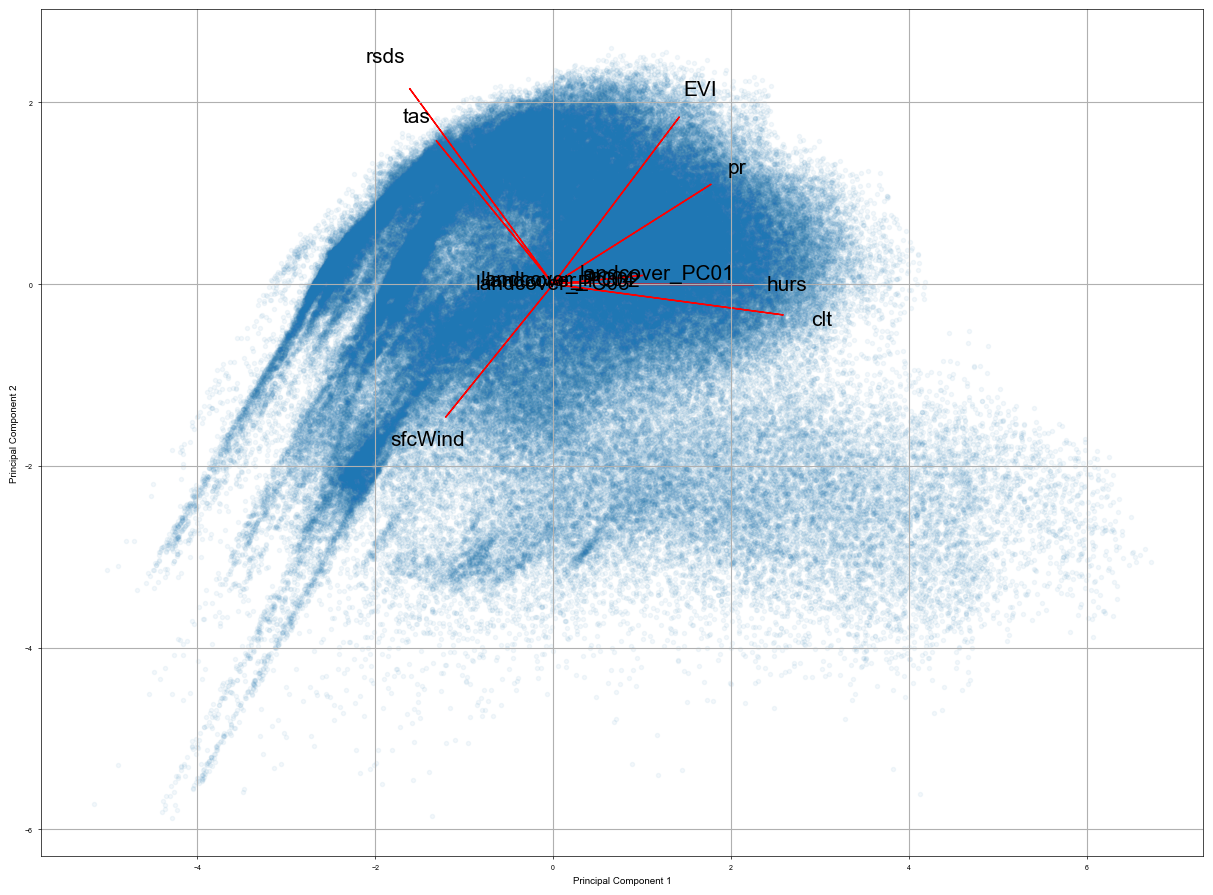

In [10]:
# Plotting the PCA results and the loadings
fig = plt.figure(figsize=(15, 11))
plt.scatter(x, y, alpha=0.05)

# Adding loading vectors
text_list = []
for i in range(PU.env_pca_loadings.shape[0]):
    plt.arrow(0, 0, PU.env_pca_loadings.loc[env_list[i], 'PC01']*3, PU.env_pca_loadings.loc[env_list[i], 'PC02']*3, color='r')
    text_list.append(plt.text(PU.env_pca_loadings.loc[env_list[i], 'PC01']*3.5, PU.env_pca_loadings.loc[env_list[i], 'PC02']*3.5, f'{env_list[i]}', color='black', ha='center', va='center', fontsize = 15))
# adjust_text(text_list)
plt.xlabel(f'Principal Component 1')
plt.ylabel(f'Principal Component 2')
plt.title('')
plt.grid(True)
plt.show()
# path_out = os.path.join(plot_path_nichespace, f'env_pca.png')
# fig.savefig(path_out, dpi = 100, transparent = False, facecolor='white',  bbox_inches='tight')